In [1]:
getwd()

[1] "/nfs/lab/scorban/jupyter_notebooks"

In [2]:
#always run this first!!
#essential reticulate functions that allow us to use python packages in R
#you'll need a conda env with 'reticulate', leidenalg' and 'pandas' installed to do this
#then route reticulate to the python installed in that conda env with the below functions
#change the path to whichever conda env you installed reticulate in
Sys.setenv(RETICULATE_PYTHON="/home/yuna/.conda/envs/reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/yuna/.conda/envs/reticulate/bin/python")
reticulate::use_condaenv("/home/yuna/.conda/envs/reticulate")
reticulate::py_module_available(module='leidenalg') #needs to be TRUE
reticulate::import('leidenalg') #good to make sure this doesn't error

[1] TRUE

Module(leidenalg)

In [3]:
#if you get messages that any of these packages aren't installed
#go ahead and locally install them yourself using install.packages()

suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
suppressMessages(library(harmony))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))
suppressMessages(library(SoupX))
suppressMessages(library(grid))
suppressMessages(library(ggplotify))
suppressMessages(library(patchwork))
suppressMessages(library(here))
suppressMessages(library(rlist))
suppressMessages(library("stringr"))
suppressMessages(library(dplyr))
#suppressMessages(library(qpdf))
library(knitr)
opts_chunk$set(tidy=TRUE)
library(SoupX)
warnLevel <- getOption('warn')
options(warn = -1)

Warning message:
“package ‘hdf5r’ was built under R version 4.2.2”


## 4 liver samples

In [ ]:
# BLOCK 1 (Comment out either all the samples, or if you want to test on one sample, 
#          you can comment out the single sample section only)
#All Samples 
#samples <- c('QY_2272_2_QY_2271_2', 'QY_2274_1_2_QY_2273_1_2', 
#             'QY_2276_2_QY_2275_2', 'QY_2278_2_QY_2277_2', 
#             'QY_2280_2_QY_2279_2', 'QY_2282_2_QY_2281_2')  
#Single Sample 
#samples <- c('QY_2272_2_QY_2271_2')

In [ ]:
# BLOCK 2
for (SAMPLE in samples){
    print(paste0("starting: ",SAMPLE))
### cellranger output directory (CHANGE path)
    wd <-sprintf('/nfs/lab/scorban/fnih_liver_231110/epigenomics.sdsc.edu/hjiao/bot_output/FNIH-liver/counts/%s/outs/',SAMPLE)
## directory to store plots (CHANGE path to demuxlet outputs)
    plots_dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s',SAMPLE)
### directory to store results (CHANGE path to demuxlet outputs. It's making the rscript2outs directory, so don't edit that end part)
    output_dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/rscript2outs',SAMPLE)
    dir.create(output_dir)
print(paste0("loading intermediate object: ",SAMPLE))
### Read in object from R script #1 (intermediate filtered rds is in the demuxlet outputs. CHANGE path to demuxlet outputs.)
    adata <- readRDS(sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/intermediate_filtered.rds',SAMPLE))
# RNA analysis (change nothing here)
    DefaultAssay(adata) <- 'RNA'
    adata <- SCTransform(adata, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
    
# ATAC analysis 
# We exclude the first dimension as this is typically correlated with sequencing depth (change nothing here)
    DefaultAssay(adata) <- 'ATAC'
    adata <- RunTFIDF(adata)
    adata <- FindTopFeatures(adata, min.cutoff='q0')
    adata <- RunSVD(adata)
    adata <- RunUMAP(adata, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
    
#read in the cellranger output per_barcode_metrics.csv file (change nothing here)
    bc_summary_fp = sprintf(paste0(wd,"per_barcode_metrics.csv"))
    bc_summary = read.table(bc_summary_fp, sep=',', header=1)
    bc_summary["new_gex_umis_count"] = bc_summary["gex_exonic_umis"] + bc_summary["gex_intronic_umis"]
    
#plot RNA UMIs (gex_exonic_umis+gex_intronic_umis) per each BC (change nothing here)
    options(repr.plot.width=6,repr.plot.height=6)
    bc_summary <- bc_summary[order(bc_summary$new_gex_umis_count, decreasing=TRUE),]
    p1 = plot(bc_summary$new_gex_umis_count, log='xy', type='l', main="RNA UMIs", 
         xlab="BC Rank", ylab="Number RNA UMIs", col='dark green', lwd=2)
    
#plot ATAC UMIs (atac_fragments) per each BC (change nothing here)
    bc_summary <- bc_summary[order(bc_summary$atac_fragments, decreasing=TRUE),]
    plot(bc_summary$atac_fragments, log='xy', type='l', main="ATAC UMIs", 
         xlab="BC Rank", ylab="Number ATAC UMIs", col='orange', lwd=2)
    
### Read in Data and Prepare Metadata
    
#get the raw and filtered (by us) RNA counts matrices
#Read in RNA assay counts from our filtered seurat object (change nothing here)
    
    DefaultAssay(adata) <- 'RNA'
    toc = GetAssayData(object = adata, slot = "counts")
    
#Read in raw RNA counts from CellRanger outputs (change nothing here)
    tod = Seurat::Read10X_h5(file.path(wd, 'raw_feature_bc_matrix.h5'))$`Gene Expression`
    
#pull out the required metadata from the clustered filtered adata object
#we need the UMAP coordinates (RD1 and RD2) and the cluster assignments at minimum
#you can also add a cluster annotations col, but that's just for plotting aesthetics 
#although it is currently required for a few plots, so I just use the cluster (change nothing here) #
    
    metadata <- (cbind(as.data.frame(adata[["umap.wnn"]]@cell.embeddings),
                       as.data.frame(Idents(adata)),
                       as.data.frame(Idents(adata))))
    colnames(metadata) <- c("RD1","RD2","Cluster","Annotation")
    
#check that the metadata BCs match the toc matrix barcodes (should all be TRUE) (change nothing here)
    metadatanames <- row.names(metadata)
    tocnames <- colnames(toc)
    table(metadatanames %in% tocnames)
    table(tocnames %in% metadatanames)
    
#doublecheck that the toc and tod indices match (should all be TRUE) (change nothing here)
    tocgenes <- row.names(tod)
    todgenes <- row.names(tod)
    table(tocgenes %in% todgenes)
    table(todgenes %in% tocgenes)
    
### Create the SoupChannel Object and Plot some Sanity Checks (change nothing here) (what are the sanity checks?)
    
    sc = SoupChannel(tod,toc)

#add in the metadate (dimensionality reduction UMAP coords and cluster assignments) (change nothing here)
    sc = setDR(sc,metadata[colnames(sc$toc),c("RD1","RD2")])
    sc = setClusters(sc,setNames(metadata$Cluster,rownames(metadata)))
    
    
## Defining the Contamination Fraction
### Option 1 - Automated method for defining noise (change nothing here)
    
    sc <- autoEstCont(sc)
    
    print(paste('Estimated global contamination fraction:',100*(sc$fit$rhoEst),"%"))
    
    background <- sc$soupProfile[order(sc$soupProfile$est,decreasing=TRUE),] 
    write.table(background,file.path(output_dir,"SoupX_estimated_background.csv"), sep='\t')
    print(paste0("finishing soupX: ",SAMPLE))

### Correct the Expression Profile (change nothing here)
    
    out = adjustCounts(sc, roundToInt=TRUE)
# Create post-SoupX Seurat Object and Add in the ATAC Windows Counts (change nothing here)

    adata2 = CreateSeuratObject(out)
    adata2[['percent.mt']] <- PercentageFeatureSet(adata2, pattern = '^MT-')
    
#add in previous raw RNA data as another assay (change nothing here)
    DefaultAssay(adata) <- 'RNA'
    raw_rna <-  GetAssayData(object = adata, slot = "counts")
    
    raw_rna_assay <- CreateAssayObject(counts = raw_rna)
    adata2[['RNA_raw']] <- raw_rna_assay
    
#pull out the RNA BCs order, for use in making the atac_counts sparse matrix (change nothing here)
    
    bc_order <- colnames(adata2[["RNA"]])
    head(bc_order)
     
### Reading in the filtered barcode list.  
    bc_fp <- file.path(output_dir,sprintf("filtered_barcodes.txt",sample))
    write(bc_order, file=bc_fp, sep = '\n')
    
    # Call the script that makes the ATAC windows matrix
    ### Read in the ATAC long format and create a sparse matrix with the desired BC order
    
    #read in the long format matrix as a table
    #gzip this in the terminals before reading in here!
        sample <- SAMPLE
    ### Update file path to outputs from the script^ (CHANGE path to demuxlet outputs dir)
        out.dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/',sample)
        atac_lfm <- read.table(file.path(out.dir, 'atac.long_fmt.filtered_barcode.mtx.gz'), sep='\t', header=FALSE, stringsAsFactors=FALSE)
        
    #we need to make sure the ATAC BCs match the one currently in adata2$RNA
    #first double check that all desired BCs are found in the ATAC BCs (and vice versa)
        table(bc_order %in% atac_lfm$V2)
        table(atac_lfm$V2 %in% bc_order)
        
    ### Read in the ATAC long format matrix and create a sparse matrix with the desired BC order
        
    #now set the levels of the lfm based on the desired bc order and reorder based on them
        atac_lfm$V2 <- factor(atac_lfm$V2, levels=bc_order)
        reordered_lfm <- atac_lfm[order(atac_lfm$V2),]
        
    #do the factoring for windows (V1) in whatever order (automatically alphanumeric?)
        reordered_lfm$V1 <- as.factor(reordered_lfm$V1)
        head(reordered_lfm)
        
    #finally make the ATAC sparse matrix and double check the BC order is correct
        atac_counts2 <- with(reordered_lfm,sparseMatrix(i=as.numeric(V1), j=as.numeric(V2), x=V3, dimnames=list(levels(V1), levels(V2))))
        table(colnames(atac_counts2) == bc_order)
        dim(atac_counts2)
        
    #assemble the other necessary components for a chromatin assay object
        grange.counts2 <- StringToGRanges(rownames(atac_counts2), sep = c('-', '-'))
        grange.use2 <- seqnames(grange.counts2) %in% standardChromosomes(grange.counts2)
        atac_counts2 <- atac_counts2[as.vector(grange.use2), ]
        annotations <- GetGRangesFromEnsDb(ensdb=EnsDb.Hsapiens.v86)
        seqlevelsStyle(annotations) <- 'UCSC'
        genome(annotations) <- 'hg38'
        
    #make the chromatin assay object and add to adata2
    #we can just use the original atac_fragments file here (produced by CellRanger)
        frag.file2 <- file.path(wd, 'atac_fragments.tsv.gz')
        chrom_assay2 <- CreateChromatinAssay(counts=atac_counts2, sep=c(':', '-'), genome='hg38', fragments=frag.file2, min.cells=0, min.features=-1, annotation=annotations)
        adata2[['ATAC']] <- chrom_assay2
    
    ########### DEMUXLET ######## (CHANGE path)
        demux <- read.table(sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/demux_out/%s.best',SAMPLE, SAMPLE), sep='\t', header=T)
        demux_sub <- demux[str_detect(demux$DROPLET.TYPE, "SNG"),]
        split_strings <- strsplit(demux_sub$BEST.GUESS, "-")
        
        # Extract the part between the 2nd and 3rd hyphen <- THIS IS CORRECT FOR LIVER
        extracted_strings <- sapply(split_strings, function(x) {
          if (length(x) >= 3) {
            return(x[3])
          } else {
            return(NA)  # If there are not enough hyphens, return NA
          }
        })
        
        # Add the extracted strings as a new column in the dataframe
        demux_sub$donor_id <- extracted_strings
        dim(demux_sub)
        head(demux_sub)
        demux_sub_filt <- demux_sub[demux_sub$BARCODE %in% colnames(adata2),]
        
        ### Add donor metadata under column 'donor_demux'
        multiome_filtered <- adata2[,colnames(adata2) %in% demux_sub_filt$BARCODE]
        rownames(demux_sub_filt) <- demux_sub_filt[,1]
        filtered_df <- demux_sub_filt$donor_id
        multiome_filtered <- AddMetaData(
                object = multiome_filtered,
                metadata = filtered_df,
                col.name = 'donor_demux'
        )
    
        print(SAMPLE)
        print(multiome_filtered)
        print(table(multiome_filtered$donor_demux))
    
        adata2 <- multiome_filtered
    
    ### Do normal multiomics analyses and plot the results
        print(paste0("processing windows-based object: ",SAMPLE))

    # RNA analysis
        DefaultAssay(adata2) <- 'RNA'
        adata2 <- SCTransform(adata2, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
        
    # ATAC analysis
    # We exclude the first dimension as this is typically correlated with sequencing depth
        DefaultAssay(adata2) <- 'ATAC'
        adata2 <- RunTFIDF(adata2)
        adata2 <- FindTopFeatures(adata2, min.cutoff='q0')
        adata2 <- RunSVD(adata2)
        adata2 <- RunUMAP(adata2, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
        
        adata2 <- FindMultiModalNeighbors(adata2, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
        adata2 <- RunUMAP(adata2, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
        adata2 <- FindClusters(adata2, graph.name='wsnn', algorithm=4, resolution = .2, verbose=FALSE, method='igraph')
        
        adata2$log_nCount_ATAC = log(adata2$nCount_ATAC)
        adata2$log_nCount_SCT = log(adata2$nCount_SCT)
        adata2$log_nFeature_ATAC = log(adata2$nFeature_ATAC)
        adata2$log_nFeature_SCT = log(adata2$nFeature_SCT)
        
        options(repr.plot.width=18, repr.plot.height=6)
        p1 <- DimPlot(adata2, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
        p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
        p2 <- DimPlot(adata2, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
        p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
        p3 <- DimPlot(adata2, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
        p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
        print(p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5)))
    
        options(repr.plot.width=24, repr.plot.height=16)
        p1 <- VlnPlot(adata2, features='nCount_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nCount_SCT), linetype='dashed', lw=2)
        p2 <- VlnPlot(adata2, features='nFeature_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_SCT), linetype='dashed', lw=2)
        p3 <- VlnPlot(adata2, features='nCount_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nCount_ATAC), linetype='dashed', lw=2)
        p4 <- VlnPlot(adata2, features='nFeature_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_ATAC), linetype='dashed', lw=2)
        p5 <- VlnPlot(adata2, features='percent.mt', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$percent.mt), linetype='dashed', lw=2)
        p6 <- VlnPlot(adata2, features='nFeature_RNA', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_SCT), linetype='dashed', lw=2)

        figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
        print(figure)
    
        path <- file.path(output_dir,'postSoupX_windows_postDemuxlet.rds')
        saveRDS(adata2, file = path)
        print(paste0("done with: ",SAMPLE))


}

In [ ]:
# BLOCK 1 (Comment out either all the samples, or if you want to test on one sample, 
#          you can comment out the single sample section only)
#All Samples 
samples <- c('QY_2270_2_QY_2269_2', 'QY_2274_1_2_QY_2273_1_2', 
             'QY_2276_2_QY_2275_2', 'QY_2278_2_QY_2277_2', 
             'QY_2280_2_QY_2279_2', 'QY_2282_2_QY_2281_2', 
             'QY_2284_1_2_QY_2283_1_2')  
#Single Sample 
#samples <- c('QY_2272_2_QY_2271_2')

In [ ]:
# BLOCK 2 (final script of the pooled multiome pipeline. )
for (SAMPLE in samples){
    print(paste0("starting: ",SAMPLE))
### cellranger output directory (CHANGE path)
    wd <-sprintf('/nfs/lab/scorban/fnih_liver_231110/epigenomics.sdsc.edu/hjiao/bot_output/FNIH-liver/counts/%s/outs/',SAMPLE)
## directory to store plots (CHANGE path to demuxlet outputs)
    plots_dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s',SAMPLE)
### directory to store results (CHANGE path to demuxlet outputs. It's making the rscript2outs directory, so don't edit that end part)
    output_dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/rscript2outs',SAMPLE)
    dir.create(output_dir)
print(paste0("loading intermediate object: ",SAMPLE))
### Read in object from R script #1 (intermediate filtered rds is in the demuxlet outputs. CHANGE path to demuxlet outputs.)
    adata <- readRDS(sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/intermediate_filtered.rds',SAMPLE))
# RNA analysis (change nothing here)
    DefaultAssay(adata) <- 'RNA'
    adata <- SCTransform(adata, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
    
# ATAC analysis 
# We exclude the first dimension as this is typically correlated with sequencing depth (change nothing here)
    DefaultAssay(adata) <- 'ATAC'
    adata <- RunTFIDF(adata)
    adata <- FindTopFeatures(adata, min.cutoff='q0')
    adata <- RunSVD(adata)
    adata <- RunUMAP(adata, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
    
#read in the cellranger output per_barcode_metrics.csv file (change nothing here)
    bc_summary_fp = sprintf(paste0(wd,"per_barcode_metrics.csv"))
    bc_summary = read.table(bc_summary_fp, sep=',', header=1)
    bc_summary["new_gex_umis_count"] = bc_summary["gex_exonic_umis"] + bc_summary["gex_intronic_umis"]
    
#plot RNA UMIs (gex_exonic_umis+gex_intronic_umis) per each BC (change nothing here)
    options(repr.plot.width=6,repr.plot.height=6)
    bc_summary <- bc_summary[order(bc_summary$new_gex_umis_count, decreasing=TRUE),]
    p1 = plot(bc_summary$new_gex_umis_count, log='xy', type='l', main="RNA UMIs", 
         xlab="BC Rank", ylab="Number RNA UMIs", col='dark green', lwd=2)
    
#plot ATAC UMIs (atac_fragments) per each BC (change nothing here)
    bc_summary <- bc_summary[order(bc_summary$atac_fragments, decreasing=TRUE),]
    plot(bc_summary$atac_fragments, log='xy', type='l', main="ATAC UMIs", 
         xlab="BC Rank", ylab="Number ATAC UMIs", col='orange', lwd=2)
    
### Read in Data and Prepare Metadata
    
#get the raw and filtered (by us) RNA counts matrices
#Read in RNA assay counts from our filtered seurat object (change nothing here)
    
    DefaultAssay(adata) <- 'RNA'
    toc = GetAssayData(object = adata, slot = "counts")
    
#Read in raw RNA counts from CellRanger outputs (change nothing here)
    tod = Seurat::Read10X_h5(file.path(wd, 'raw_feature_bc_matrix.h5'))$`Gene Expression`
    
#pull out the required metadata from the clustered filtered adata object
#we need the UMAP coordinates (RD1 and RD2) and the cluster assignments at minimum
#you can also add a cluster annotations col, but that's just for plotting aesthetics 
#although it is currently required for a few plots, so I just use the cluster (change nothing here) #
    
    metadata <- (cbind(as.data.frame(adata[["umap.wnn"]]@cell.embeddings),
                       as.data.frame(Idents(adata)),
                       as.data.frame(Idents(adata))))
    colnames(metadata) <- c("RD1","RD2","Cluster","Annotation")
    
#check that the metadata BCs match the toc matrix barcodes (should all be TRUE) (change nothing here)
    metadatanames <- row.names(metadata)
    tocnames <- colnames(toc)
    table(metadatanames %in% tocnames)
    table(tocnames %in% metadatanames)
    
#doublecheck that the toc and tod indices match (should all be TRUE) (change nothing here)
    tocgenes <- row.names(tod)
    todgenes <- row.names(tod)
    table(tocgenes %in% todgenes)
    table(todgenes %in% tocgenes)
    
### Create the SoupChannel Object and Plot some Sanity Checks (change nothing here) (what are the sanity checks?)
    
    sc = SoupChannel(tod,toc)

#add in the metadate (dimensionality reduction UMAP coords and cluster assignments) (change nothing here)
    sc = setDR(sc,metadata[colnames(sc$toc),c("RD1","RD2")])
    sc = setClusters(sc,setNames(metadata$Cluster,rownames(metadata)))
    
    
## Defining the Contamination Fraction
### Option 1 - Automated method for defining noise (change nothing here)
    
    sc <- autoEstCont(sc)
    
    print(paste('Estimated global contamination fraction:',100*(sc$fit$rhoEst),"%"))
    
    background <- sc$soupProfile[order(sc$soupProfile$est,decreasing=TRUE),] 
    write.table(background,file.path(output_dir,"SoupX_estimated_background.csv"), sep='\t')
    print(paste0("finishing soupX: ",SAMPLE))

### Correct the Expression Profile (change nothing here)
    
    out = adjustCounts(sc, roundToInt=TRUE)
# Create post-SoupX Seurat Object and Add in the ATAC Windows Counts (change nothing here)

    adata2 = CreateSeuratObject(out)
    adata2[['percent.mt']] <- PercentageFeatureSet(adata2, pattern = '^MT-')
    
#add in previous raw RNA data as another assay (change nothing here)
    DefaultAssay(adata) <- 'RNA'
    raw_rna <-  GetAssayData(object = adata, slot = "counts")
    
    raw_rna_assay <- CreateAssayObject(counts = raw_rna)
    adata2[['RNA_raw']] <- raw_rna_assay
    
#pull out the RNA BCs order, for use in making the atac_counts sparse matrix (change nothing here)
    
    bc_order <- colnames(adata2[["RNA"]])
    head(bc_order)
     
### Reading in the filtered barcode list.  
    bc_fp <- file.path(output_dir,sprintf("filtered_barcodes.txt",sample))
    write(bc_order, file=bc_fp, sep = '\n')
    
    # Call the script that makes the ATAC windows matrix
    ### Read in the ATAC long format and create a sparse matrix with the desired BC order
    
    #read in the long format matrix as a table
    #gzip this in the terminals before reading in here!
        sample <- SAMPLE
    ### Update file path to outputs from the script^ (CHANGE path to demuxlet outputs dir)
        out.dir <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/',sample)
        atac_lfm <- read.table(file.path(out.dir, 'atac.long_fmt.filtered_barcode.mtx.gz'), sep='\t', header=FALSE, stringsAsFactors=FALSE)
        
    #we need to make sure the ATAC BCs match the one currently in adata2$RNA
    #first double check that all desired BCs are found in the ATAC BCs (and vice versa)
        table(bc_order %in% atac_lfm$V2)
        table(atac_lfm$V2 %in% bc_order)
        
    ### Read in the ATAC long format matrix and create a sparse matrix with the desired BC order
        
    #now set the levels of the lfm based on the desired bc order and reorder based on them
        atac_lfm$V2 <- factor(atac_lfm$V2, levels=bc_order)
        reordered_lfm <- atac_lfm[order(atac_lfm$V2),]
        
    #do the factoring for windows (V1) in whatever order (automatically alphanumeric?)
        reordered_lfm$V1 <- as.factor(reordered_lfm$V1)
        head(reordered_lfm)
        
    #finally make the ATAC sparse matrix and double check the BC order is correct
        atac_counts2 <- with(reordered_lfm,sparseMatrix(i=as.numeric(V1), j=as.numeric(V2), x=V3, dimnames=list(levels(V1), levels(V2))))
        table(colnames(atac_counts2) == bc_order)
        dim(atac_counts2)
        
    #assemble the other necessary components for a chromatin assay object
        grange.counts2 <- StringToGRanges(rownames(atac_counts2), sep = c('-', '-'))
        grange.use2 <- seqnames(grange.counts2) %in% standardChromosomes(grange.counts2)
        atac_counts2 <- atac_counts2[as.vector(grange.use2), ]
        annotations <- GetGRangesFromEnsDb(ensdb=EnsDb.Hsapiens.v86)
        seqlevelsStyle(annotations) <- 'UCSC'
        genome(annotations) <- 'hg38'
        
    #make the chromatin assay object and add to adata2
    #we can just use the original atac_fragments file here (produced by CellRanger)
        frag.file2 <- file.path(wd, 'atac_fragments.tsv.gz')
        chrom_assay2 <- CreateChromatinAssay(counts=atac_counts2, sep=c(':', '-'), genome='hg38', fragments=frag.file2, min.cells=0, min.features=-1, annotation=annotations)
        adata2[['ATAC']] <- chrom_assay2
    
    ########### DEMUXLET ######## (CHANGE path)
        demux <- read.table(sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/demux_out/%s.best',SAMPLE, SAMPLE), sep='\t', header=T)
        demux_sub <- demux[str_detect(demux$DROPLET.TYPE, "SNG"),]
        split_strings <- strsplit(demux_sub$BEST.GUESS, "-")
        
        # Extract the part between the 2nd and 3rd hyphen <- THIS IS CORRECT FOR LIVER
        extracted_strings <- sapply(split_strings, function(x) {
          if (length(x) >= 3) {
            return(x[3])
          } else {
            return(NA)  # If there are not enough hyphens, return NA
          }
        })
        
        # Add the extracted strings as a new column in the dataframe
        demux_sub$donor_id <- extracted_strings
        dim(demux_sub)
        head(demux_sub)
        demux_sub_filt <- demux_sub[demux_sub$BARCODE %in% colnames(adata2),]
        
        ### Add donor metadata under column 'donor_demux'
        multiome_filtered <- adata2[,colnames(adata2) %in% demux_sub_filt$BARCODE]
        rownames(demux_sub_filt) <- demux_sub_filt[,1]
        filtered_df <- demux_sub_filt$donor_id
        multiome_filtered <- AddMetaData(
                object = multiome_filtered,
                metadata = filtered_df,
                col.name = 'donor_demux'
        )
    
        print(SAMPLE)
        print(multiome_filtered)
        print(table(multiome_filtered$donor_demux))
    
        adata2 <- multiome_filtered
    
    ### Do normal multiomics analyses and plot the results
        print(paste0("processing windows-based object: ",SAMPLE))

    # RNA analysis
        DefaultAssay(adata2) <- 'RNA'
        adata2 <- SCTransform(adata2, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
        
    # ATAC analysis
    # We exclude the first dimension as this is typically correlated with sequencing depth
        DefaultAssay(adata2) <- 'ATAC'
        adata2 <- RunTFIDF(adata2)
        adata2 <- FindTopFeatures(adata2, min.cutoff='q0')
        adata2 <- RunSVD(adata2)
        adata2 <- RunUMAP(adata2, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
        
        adata2 <- FindMultiModalNeighbors(adata2, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
        adata2 <- RunUMAP(adata2, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
        adata2 <- FindClusters(adata2, graph.name='wsnn', algorithm=4, resolution = .2, verbose=FALSE, method='igraph')
        
        adata2$log_nCount_ATAC = log(adata2$nCount_ATAC)
        adata2$log_nCount_SCT = log(adata2$nCount_SCT)
        adata2$log_nFeature_ATAC = log(adata2$nFeature_ATAC)
        adata2$log_nFeature_SCT = log(adata2$nFeature_SCT)
        
        options(repr.plot.width=18, repr.plot.height=6)
        p1 <- DimPlot(adata2, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
        p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
        p2 <- DimPlot(adata2, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
        p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
        p3 <- DimPlot(adata2, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
        p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
        print(p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5)))
    
        options(repr.plot.width=24, repr.plot.height=16)
        p1 <- VlnPlot(adata2, features='nCount_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nCount_SCT), linetype='dashed', lw=2)
        p2 <- VlnPlot(adata2, features='nFeature_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_SCT), linetype='dashed', lw=2)
        p3 <- VlnPlot(adata2, features='nCount_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nCount_ATAC), linetype='dashed', lw=2)
        p4 <- VlnPlot(adata2, features='nFeature_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_ATAC), linetype='dashed', lw=2)
        p5 <- VlnPlot(adata2, features='percent.mt', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$percent.mt), linetype='dashed', lw=2)
        p6 <- VlnPlot(adata2, features='nFeature_RNA', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata2$nFeature_SCT), linetype='dashed', lw=2)

        figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
        print(figure)
    
        path <- file.path(output_dir,'postSoupX_windows_postDemuxlet.rds')
        saveRDS(adata2, file = path)
        print(paste0("done with: ",SAMPLE))


}

In [ ]:
adata2

# Merge pools

In [ ]:
#This will need to be majorly updated for heart. For liver, it is finding the mvf off of the previous 4 liver lanes, which is great. But for heart, we will need to make mvf off of 4 of the lanes. 
#### FOR LIVER: since we already have a merged object for the last pool 
### current object is /nfs/lab/rlmelton/npod/notebooks/sherlock/fNIH_projects/101523_fNIH_liver_merge_correctDemux.rds
### read that in here:
curr_obj <- readRDS('/nfs/lab/rlmelton/npod/notebooks/sherlock/fNIH_projects/101523_fNIH_liver_merge_correctDemux.rds')
curr_obj$batch <- 'firstPR'
## GET LIST OF HIGHLY VARIABLE WINDOWS FROM CURRENT OBJECT TO SUBSET THE NEW LANE ATAC 
## WINDOWS BY SO WE CAN COMBINE THE DATA


HVWs <- (rownames(curr_obj@assays$windows@counts))
head(HVWs)

hvws_fin2 <- sort(HVWs)
print(length(hvws_fin2))

#Talk to rebecca when new liver data is generated. Because we will need to read in the 4+8 lane merged data here, and not call it pool 1. So will need to update code. And rebecca is down to help. 
#Will also need to change "secondPR" in a couple blocks below, to whatever pool round we're on. 


In [ ]:
head(hvws_fin2)

In [ ]:
curr_obj <- FindTopFeatures(curr_obj, min.cutoff='q75', verbose=FALSE)
curr_obj

In [ ]:
##Finding Highly Variable Windows and subsetting to 50k most variable. In the future, all you need to do is read in the variable window file that this is creating, to cut down all the pools to this window set. So will not need to run this block of code again in the future. 
#Will need to remake current object to be subsetted off of these 50k windows 
# Find variable features
hvw <- FindVariableFeatures(object = curr_obj[['windows']][], selection.method = "vst")

# Plot variability vs average expression 
ggplot(hvw) + geom_point(aes(x=vst.mean, y=vst.variance.standardized))

# Pull out 50k most variable windows
temp <- hvw[order(hvw$vst.variance.standardized),]
hvw_cut <- temp[seq(1,50000),]
hvws <- row.names(hvw_cut)

#save this list to a file (just the windows names)
fp <- '/nfs/lab/scorban/fnih_liver_231110/intregration/Jan18_2024_seuratintegration/fnihliver_firstpool_4lanes_HVWs50K.txt'
write(hvws, file=fp, sep = '\n')

In [ ]:
#Error in the plotting above, so skipping plotting and running last to sections that didn't run bc of the plot error. 
# Pull out 50k most variable windows
temp <- hvw[order(hvw$vst.variance.standardized),]
hvw_cut <- temp[seq(1,50000),]
hvws <- row.names(hvw_cut)

#save this list to a file (just the windows names)
fp <- '/nfs/lab/scorban/fnih_liver_231110/intregration/Jan18_2024_seuratintegration/fnihliver_firstpool_4lanes_HVWs50K.txt'
write(hvws, file=fp, sep = '\n')

In [ ]:
head(hvws)

In [ ]:
#head(curr_obj@assays$windows@var.features)

In [ ]:
### CHANGE SAMPLE NAMES 
samples <- c('QY_2270_2_QY_2269_2', 'QY_2272_2_QY_2271_2', 'QY_2274_1_2_QY_2273_1_2', 
             'QY_2276_2_QY_2275_2', 'QY_2278_2_QY_2277_2', 
             'QY_2280_2_QY_2279_2', 'QY_2282_2_QY_2281_2', 
             'QY_2284_1_2_QY_2283_1_2')  

In [ ]:
#This is just loading in the seurat objects made above (the object after soupx,windows,demux) we read in the RNA, ATAC, and normalization method (SCT), but only keep the RNA seurat object. 
adatas <- list()
for (sample in samples){
    adata <- readRDS(file = sprintf("/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/rscript2outs/postSoupX_windows_postDemuxlet.rds",sample))
    print(adata)
    adatas[[sample]] <- adata
    DefaultAssay(adatas[[sample]]) <- "RNA"
    adatas[[sample]][['ATAC']] <- NULL
    adatas[[sample]][['SCT']] <- NULL
    #adatas[[sample]][['RNA_raw']] <- NULL

}


In [ ]:
#Edit nothing here for the second liver pool. Note that this will add a metadata column called "secondPR" pool round, so that when we merge the first and second pool rounds, if we have to batch correct by pool, the metadata is already there
#This will merge the lanes. Then add the lane info metadata column. Then add the pool metadata. 
adata_new <- merge(adatas[[samples[[1]]]], y=adatas[samples[2:length(samples)]], add.cell.ids=samples, project='fNIH_liver')
adata_new$lane <- sub("^(([^_]*_){7}[^_]*)_.*$", "\\1", rownames(adata_new@meta.data))
adata_new$batch <- 'secondPR'
head(adata_new@meta.data)
adata_new

#WILL NEED TO EDIT in the future: When running this in the future, will need to change "secondPR" to whatever pooling round (PR) we're on for the liver data. 

In [ ]:
#read in ATAC data from the lfm matrices (sm workaround method for now)
# load in starting ATAC long format matrices to a list(CellRanger filtered for now), then filters them down and merges them all together. 
#UPDATE the path to wherever the long format matrices data is. Ensure the correct file, and update file name if needed (aka the atac.long_...)

atacs_OG <- list()
atacs_FINAL <- list()

for (sample in samples) {
    #print(sample)
    #### REPLACE PATHS
    wd <- sprintf('/nfs/lab/scorban/fnih_liver_231110/demuxlet_results/results1Mvariants/%s/',sample)
    atacs_OG[[sample]] <- read.table(file.path(wd, 'atac.long_fmt.filtered_barcode.mtx.gz'), sep='\t', header=FALSE, stringsAsFactors=FALSE)
    atacs_OG[[sample]]$V1 <- as.factor(atacs_OG[[sample]]$V1)
    atacs_OG[[sample]]$V2 <- as.factor(atacs_OG[[sample]]$V2)
    
    atacs_FINAL[[sample]] <- atacs_OG[[sample]]
    atacs_FINAL[[sample]]$V2 <- paste0(sample,'_',atacs_FINAL[[sample]]$V2)

        
}



In [ ]:
#function which takes in a list of long format atac_fragment dataframes with 
#sample names (df), an overall windows file (windows) and then makes these 
#into sparse matrices and merges them together

#modified to take in the hvws set and use those... will still check if 
#there's any missing windows and add those, so only a few changes!
#CHANGE NOTHING, just need to run it everytime to make the function, that will be called later. 

merge_sparse_matrices_hvws <- function(dfs, windows){
    samples <- names(dfs)
    for (sample in samples){
        #get missing windows list for this sample
        print(paste(sample,Sys.time(),sep=': '))
        df <- dfs[[sample]]
        mis_windows <- windows[!windows %in% levels(df$V1)]
        
        #make sure there are missing_windows
        if (length(mis_windows) > 0){
            print('Adding missing windows')
            #create a new long format matrix (sm) with the missing windows added as 0 counts
            filler_bc <- as.character(df$V2[[1]])
            print(paste("Using filler BC:",filler_bc,sep=" "))
            new_rows <- cbind(as.data.frame(mis_windows),
                              as.data.frame(rep(filler_bc),length(mis_windows)),
                              as.data.frame(rep(0,length(mis_windows))))
            colnames(new_rows) <- c("V1","V2","V3")
            lfm <- rbind(df,new_rows)
        #if there aren't, set lfm to df
        } else {
            print('No windows were missing')
            lfm <- df
        }
        
        #cut down lfm to just be the hvws (windows)
        lfm_cut <- lfm[lfm$V1 %in% windows,]
        
        #set the levels of the lfm based on the desired bc order and reorder V1
        lfm_cut$V1 <- factor(lfm_cut$V1, levels=windows)
        lfm2 <- lfm_cut[order(lfm_cut$V1),]
        lfm2$V2 <- as.factor(lfm2$V2)
        
        if (sample == samples[1]){
            #if first sample, will make the overall sparse matrix 
            overall_sm <- with(lfm2,sparseMatrix(i=as.numeric(V1), j=as.numeric(V2), x=V3, dimnames=list(levels(V1), levels(V2))))
            print(dim(overall_sm))
            
        } else {
            #otherwise, convert into a sparse matrix and add to the overall one
            sm = with(lfm2,sparseMatrix(i=as.numeric(V1), j=as.numeric(V2), x=V3, dimnames=list(levels(V1), levels(V2))))
            print(dim(sm))
            overall_sm = cbind(overall_sm, sm) 
        }
    }
    return(overall_sm)
}

In [ ]:
hvws_fin2 <- sort(hvws)

In [ ]:
#this will print out a list of windows. This mostly lets us know it exists and is formated correctly. Should be formatted like this: 'chr1-10000-15000' 
head(hvws_fin2)

In [ ]:
#Calling the function written in two code blocks above. Note, sparse matrices just use dots intead of zeros, which makes it smaller to store. 
#CHANGE NOTHING HERE, just doublecheck that it doesn't error. If things are fucked up we will get a "cholmod error"
#first number under using filler BC should say 50000
overall_sm2 <- merge_sparse_matrices_hvws(atacs_FINAL,hvws_fin2)
dim(overall_sm2)
head(overall_sm2)

In [ ]:
head(atacs_FINAL)



In [ ]:
#check if the windows of overall_sm are sorted (they should be)
#CHANGE NOTHING HERE. Should print TRUE. 
sorted_windows2 <- sort(row.names(overall_sm2))
table(sorted_windows2 == row.names(overall_sm2))

In [ ]:
#make sure number of columns match the RNA object
#CHANGE NOTHING HERE. Just make sure number from above block matches the number below. (first number is rows, second is column. just make sure rows match the above with TRUE)
good <- rownames(adata_new@meta.data)
overall_sm3 <- overall_sm2[,colnames(overall_sm2) %in% good]
dim(overall_sm3) 

In [ ]:
# triple check that all the barcodes in the RNA object are in the atac sparse matrix (number here should match second number, column, from above. and print TRUE.)
#CHANGE NOTHING HERE (just check for TRUE.)
bc_lfm <- sort(colnames(overall_sm3))
bc_rna <- sort(good)
table(bc_lfm == bc_rna)

In [ ]:
#CHANGE NOTHING HERE. Unless you change genomes. In which case, just change the hg38 notation to whateveer genome you're using. Change nothing else.)
atac <- overall_sm3
#continue to make Seurat compatible object (making sparse matrix above into a seurat assay)
suppressMessages(annotations <- GetGRangesFromEnsDb(ensdb=EnsDb.Hsapiens.v86))
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- 'hg38'

#### Make merge fragment
```bash
for SAMPLE in HPAP-36 HPAP-37; do zcat /nfs/lab/rlmelton/npod/cellrangerOUtput/${SAMPLE}/outs/fragments.tsv.gz | awk -v SAMPLE=$SAMPLE \ 'BEGIN{FS=OFS="\t"} {print $1,$2,$3,SAMPLE"_"$4,$5}'; done | sort -k1,1 -k2,2n -S 64G | bgzip -c -@ 16 > /nfs/lab/rlmelton/npod/integration/nov18_seuratIntegration/merged.atac_fragments_new.tsv.gz 

# after running the above in a screen, in the path where the file is, run the following, updating the file path. This code is creating an index file for the merged.tsv 

tabix -p bed /nfs/lab/rlmelton/npod/integration/nov18_seuratIntegration/merged.atac_fragments_new.tsv.gz
```

In [ ]:
#UPDATE path to merged.atac_fragments.tsv.gz file 
frag.file = '/nfs/lab/scorban/fnih_liver_231110/intregration/Jan18_2024_seuratintegration/merged.atac_fragments_new.tsv.gz'

In [ ]:
#CHANGE NOTHING HERE 
#Creates a chromatin assay, matrix made, fragments that just got read in, and genome annotation, to create a chromatin assay that we'll add to the merged seurat object. 
#Chromatin assay is just matrices of matrices (a specific way of storing atac data that can then be added to a seurat object. within an object you can have multiple code/computer/modality assays)
atac_assay <- CreateChromatinAssay(counts=overall_sm3, sep=c('-', '-'), genome='hg38', fragments=frag.file, min.cells=0, min.features=-1, annotation=annotations)
atac_assay


In [ ]:
#Not needed, but feel free to do it. 
head(overall_sm3)

In [ ]:
head(atac_assay)
head(atac_assay@counts)
#don't need to do but feel free if wanted. 

In [ ]:
#Taking new chromatin assay created and adding to the merged seurat object, and calling it "windows" 
#CHANGE NOTHING HERE
adata_new[["windows"]] <- atac_assay

In [ ]:
#Saving the merged seurat object, so I can clear the memory in the notebook
saveRDS(adata_new,'/nfs/lab/scorban/fnih_liver_231110/intregration/Jan18_2024_seuratintegration/Jan23_2024_secondpool_24donors_8lanes_mergedseuratobject.rds')

In [ ]:
#Need to subset the 4 lanes off of the 50k hvws, and make a new object of the previous 4 lanes.
# Rebecca to send over new code 

In [ ]:
#After restarting the notebook to clear memory, read in the 4 lane seurat object and the 8 lane seurat object. Then proceed to merging 
adata_new <- readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan18_2024_seuratintegration/Jan23_2024_secondpool_24donors_8lanes_mergedseuratobject.rds')
curr_obj <- readRDS('/nfs/lab/rlmelton/npod/notebooks/sherlock/fNIH_projects/012224_fNIH_liver_merge_correctDemux_50kHVWs.rds')

In [ ]:
adata_new
curr_obj

In [ ]:
### MERGE THESE 8 WITH ORIGINAL 4
#adata_new is the new seurat object made with the 8 lanes. Curr_obj is the merged 4 lanes previously done.  Now we will merge them together. 
#Should work fine, but might throw errors. Talk with Rebecca. 
#CHANGE NOTHING HERE. Will take a hot second to run, because merging a lot. 
adata <- merge(curr_obj, y= adata_new)

In [ ]:
#will print out the new seurat object that we're using (both pools merged into one)
adata

In [ ]:
### CHANGE NAME (include which pools are in it and the date)
#This will save it immediately to wherever your notebook is currently at. 
#To see where notebook is use getwd() (get working directory)
saveRDS(adata,'/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs.rds')

In [ ]:
#### STOP: AT THIS POINT I WOULD RESTART THE NOTEBOOK AND CLEAR OUT THE MEMORY (kernel --> restart) 
#### THEN LOAD IN THE OBJECT ABOVE AND CONTINUE ON (update object name to whatever it is above) and make sure to run the first 3 code blocks!!!
adata<-readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs.rds')

In [ ]:
adata

In [ ]:
#Just printing out some quick stats. How many cells are in each lane. How many cells per donor across all lanes. Then how many cells come from each batch (pool 1, pool 3, etc)
#CHANGE NOTHING
table(adata$lane)
table(adata$donor_demux)
table(adata$batch)

In [ ]:
#Cells per donor, in a txt file you can send to ppl or put in excel and plot things, etc. 
#CHANGE NOTHING
write.table(table(adata$donor_demux), "/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/liver_cellCount_byDonor.txt", sep = '\t', quote = FALSE, col.names = FALSE, row.names = FALSE)

In [ ]:
#Will print out object again. Numbers will continue to increase. 
#CHANGE NOTHING HERE 
adata

In [ ]:
library(stringr)
adata$lane <- str_sub(rownames(adata@meta.data), end=-20)

In [ ]:
head(adata@meta.data) 

In [ ]:
unique(adata@meta.data$lane)

In [ ]:
# RNA analysis
#taking seurat object, and doing rna analysis (normalization, pca, harmony batch correction method - correcting by donor, lane, and batch currently). 
#Currently do not need to change anything. But as a test, drop donor as a batch correction. 
DefaultAssay(adata) <- 'RNA'
suppressWarnings(adata <- SCTransform(adata, verbose=FALSE))
adata <- RunPCA(adata)
adata <- RunHarmony(adata, group.by.vars=c('donor_demux','lane', 'batch'), assay.use='SCT', reduction.save='harmony.rna')
adata <- RunUMAP(adata, dims=1:50, reduction='harmony.rna', reduction.name='umap.rna', reduction.key='rnaUMAP_')
#adata <- RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')



In [ ]:
# ATAC analysis (currently windows based, not peaks based)
# We exclude the first dimension as this is typically correlated with sequencing depth
#Normalization, figuring out which windows are the most important, can add a min cutoff flag in the findtopfeatures section, min.cutoff='q75', or something, if desired. Change the q## if looks like shit, chat with rebecca prior to changing. But could be possibly because we used too few windows for the clustering, in which case we need more windows for clustering.
#rn batch correcting with harmony for donor, lane, and pool batch. In the future, run with just lane and pool batch, removing donor in the "c"
#DON'T CHANGE anything except comment above, if desired. 
DefaultAssay(adata) <- 'windows'
adata <- RunTFIDF(adata)
adata <- FindTopFeatures(adata, verbose=FALSE)
adata <- RunSVD(adata)
hm_atac <- HarmonyMatrix(Embeddings(adata, reduction='lsi'),  adata@meta.data, c('donor_demux','lane','batch'),do_pca=FALSE)
adata[['harmony.atac']] <- CreateDimReducObject(embeddings=hm_atac, key='atac_', assay='windows')
adata <- RunUMAP(adata, dims=2:50, reduction='harmony.atac', reduction.name='umap.atac', reduction.key='atacUMAP_')
#adata <- RunUMAP(adata, dims=2:50, reduction='lsi', reduction.name='umap.atac', reduction.key='atacUMAP_')



In [ ]:
# Combining RNA and ATAC Modalities to get weighted nearest neighbors. 
#CHANGE NOTHING 
#adata <- FindMultiModalNeighbors(adata, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
adata <- FindMultiModalNeighbors(adata, reduction.list=list('harmony.rna', 'harmony.atac'), dims.list=list(1:50, 2:50))
adata <- RunUMAP(adata, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
#mem_change(adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.5, verbose=FALSE))
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.25, verbose=FALSE, method = 'igraph')

adata$log_nCount_ATAC=log(adata$nCount_windows)
adata$log_nCount_SCT=log(adata$nCount_SCT)
adata$log_nFeature_ATAC=log(adata$nFeature_windows)
adata$log_nFeature_SCT=log(adata$nFeature_SCT)

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#cell counts per cluster
table(adata$seurat_clusters)

In [ ]:
#CHANGE NOTHING
#Making UMAPS but colored by donor. Hoping all donors are represented in all clusters. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by lane. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by pooling batch.  
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by lane. 
#Interpretation: if any of them are far from the others. 
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE -- but changing some numbers to make the plots more readable, trial  
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by seurat clusters  
#Interpretation: we want these to be distinct from each other because theoretically they are different cell types/populations. So more variability is okay.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by pooling batch   
#Interpretation: Ideally we do not want much variability by pooling batch.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#Note to SIERRA, might need to edit this to include batch...??? Ask Rebecca 
options(repr.plot.width=40, repr.plot.height=15)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', split.by='donor_demux', label=FALSE, label.size=6, repel=TRUE)
adata$value <- 1
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p1 / p2

In [ ]:
options(repr.plot.width=20, repr.plot.height=5)
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p2

In [ ]:
table(adata$seurat_clusters, adata$donor_demux)

In [ ]:
adata$donor_demux

In [ ]:
#Ideally, finding markers that define cluster 9. 
#trying with one cluster, before running find markers on all clusters. 
cluster9.markers <- FindMarkers(adata, ident.1 = 9)
head(cluster9.markers, n = 5)

In [ ]:
head(cluster9.markers, n = 5)

In [ ]:
suppressMessages(library(FindMarkers))
#suppressMessages(library(qpdf))
library(knitr)
opts_chunk$set(tidy=TRUE)
library(SoupX)
warnLevel <- getOption('warn')
options(warn = -1)

In [ ]:
unique(adata@meta.data$donor_demux)

In [ ]:
getwd()

In [ ]:
saveRDS(adata,'/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/Jan24_2024_fnih_liver_pools1and2_12lanes_40donors_finalmerged_savingagaintoensuresaved.rds')

In [ ]:
#END (I think...)

# Redoing batch correction and clustering NOT considering donor as a covariate (bc data is pooled) 

In [ ]:
#### STOP: AT THIS POINT I WOULD RESTART THE NOTEBOOK AND CLEAR OUT THE MEMORY (kernel --> restart) 
#### THEN LOAD IN THE OBJECT ABOVE AND CONTINUE ON (update object name to whatever it is above) and make sure to run the first 3 code blocks!!!
adata<-readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs.rds')

In [ ]:
adata

In [ ]:
library(stringr)
adata$lane <- str_sub(rownames(adata@meta.data), end=-20)

In [ ]:
unique(adata@meta.data$lane)

In [ ]:
#Just printing out some quick stats. How many cells are in each lane. How many cells per donor across all lanes. Then how many cells come from each batch (pool 1, pool 3, etc)
#CHANGE NOTHING
table(adata$lane)
table(adata$donor_demux)
table(adata$batch)

In [ ]:
head(adata@meta.data)

In [ ]:
unique(adata@meta.data$donor_demux)

In [ ]:
#Cells per donor, in a txt file you can send to ppl or put in excel and plot things, etc. 
#CHANGE NOTHING
write.table(table(adata$donor_demux), "/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/liver_cellCount_byDonor.txt", sep = '\t', quote = FALSE, col.names = FALSE, row.names = FALSE)

In [ ]:
#Will print out object again. Numbers will continue to increase. 
#CHANGE NOTHING HERE 
adata

In [ ]:
# RNA analysis
#taking seurat object, and doing rna analysis (normalization, pca, harmony batch correction method - correcting by donor, lane, and batch currently). 
#Currently do not need to change anything. But as a test, drop donor as a batch correction. 
DefaultAssay(adata) <- 'RNA'
suppressWarnings(adata <- SCTransform(adata, verbose=FALSE))
adata <- RunPCA(adata)
adata <- RunHarmony(adata, group.by.vars=c('lane', 'batch'), assay.use='SCT', reduction.save='harmony.rna')
adata <- RunUMAP(adata, dims=1:50, reduction='harmony.rna', reduction.name='umap.rna', reduction.key='rnaUMAP_')
#adata <- RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')



In [ ]:
# ATAC analysis (currently windows based, not peaks based)
# We exclude the first dimension as this is typically correlated with sequencing depth
#Normalization, figuring out which windows are the most important, can add a min cutoff flag in the findtopfeatures section, min.cutoff='q75', or something, if desired. Change the q## if looks like shit, chat with rebecca prior to changing. But could be possibly because we used too few windows for the clustering, in which case we need more windows for clustering.
#rn batch correcting with harmony for donor, lane, and pool batch. In the future, run with just lane and pool batch, removing donor in the "c"
#DON'T CHANGE anything except comment above, if desired. 
DefaultAssay(adata) <- 'windows'
adata <- RunTFIDF(adata)
adata <- FindTopFeatures(adata, verbose=FALSE)
adata <- RunSVD(adata)
hm_atac <- HarmonyMatrix(Embeddings(adata, reduction='lsi'),  adata@meta.data, c('lane','batch'),do_pca=FALSE)
adata[['harmony.atac']] <- CreateDimReducObject(embeddings=hm_atac, key='atac_', assay='windows')
adata <- RunUMAP(adata, dims=2:50, reduction='harmony.atac', reduction.name='umap.atac', reduction.key='atacUMAP_')
#adata <- RunUMAP(adata, dims=2:50, reduction='lsi', reduction.name='umap.atac', reduction.key='atacUMAP_')



In [ ]:
# Combining RNA and ATAC Modalities to get weighted nearest neighbors. 
#CHANGE NOTHING 
#adata <- FindMultiModalNeighbors(adata, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
adata <- FindMultiModalNeighbors(adata, reduction.list=list('harmony.rna', 'harmony.atac'), dims.list=list(1:50, 2:50))
adata <- RunUMAP(adata, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
#mem_change(adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.5, verbose=FALSE))
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.25, verbose=FALSE, method = 'igraph')

adata$log_nCount_ATAC=log(adata$nCount_windows)
adata$log_nCount_SCT=log(adata$nCount_SCT)
adata$log_nFeature_ATAC=log(adata$nFeature_windows)
adata$log_nFeature_SCT=log(adata$nFeature_SCT)

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#cell counts per cluster
table(adata$seurat_clusters)

In [ ]:
#CHANGE NOTHING
#Making UMAPS but colored by donor. Hoping all donors are represented in all clusters. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by lane. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by pooling batch.  
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by lane. 
#Interpretation: if any of them are far from the others. 
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE -- but changing some numbers to make the plots more readable, trial  
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=25, repr.plot.height=30)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2) + theme(axis.text = element_text(size = 15))
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p2 & NoLegend(), p3 & NoLegend(), p4 & NoLegend(), p5 & NoLegend(), p6 & NoLegend(), ncol = 1, nrow = 6)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by seurat clusters  
#Interpretation: we want these to be distinct from each other because theoretically they are different cell types/populations. So more variability is okay.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by pooling batch   
#Interpretation: Ideally we do not want much variability by pooling batch.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#Note to SIERRA, might need to edit this to include batch...??? Ask Rebecca 
options(repr.plot.width=40, repr.plot.height=15)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', split.by='donor_demux', label=FALSE, label.size=10, repel=TRUE)
adata$value <- 1
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p1 / p2

In [ ]:
options(repr.plot.width=20, repr.plot.height=5)
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p2

In [ ]:
table(adata$seurat_clusters, adata$donor_demux)

In [ ]:
adata$donor_demux

In [ ]:
saveRDS(adata,'/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_LaneAndPoolingBatch.rds')

# Redoing batch correction and clustering NOT considering lane as a covariate (only Donor and Pooling Batch) 

In [ ]:
#### STOP: AT THIS POINT I WOULD RESTART THE NOTEBOOK AND CLEAR OUT THE MEMORY (kernel --> restart) 
#### THEN LOAD IN THE OBJECT ABOVE AND CONTINUE ON (update object name to whatever it is above) and make sure to run the first 3 code blocks!!!
adata<-readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs.rds')

In [ ]:
adata

In [ ]:
library(stringr)
adata$lane <- str_sub(rownames(adata@meta.data), end=-20)

In [ ]:
unique(adata@meta.data$lane)

In [ ]:
#Just printing out some quick stats. How many cells are in each lane. How many cells per donor across all lanes. Then how many cells come from each batch (pool 1, pool 3, etc)
#CHANGE NOTHING
table(adata$lane)
table(adata$donor_demux)
table(adata$batch)

In [ ]:
head(adata@meta.data)

In [ ]:
unique(adata@meta.data$donor_demux)

In [ ]:
#Cells per donor, in a txt file you can send to ppl or put in excel and plot things, etc. 
#CHANGE NOTHING 
#don't need to do this for the recluster 
#write.table(table(adata$donor_demux), "/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/liver_cellCount_byDonor.txt", sep = '\t', quote = FALSE, col.names = FALSE, row.names = FALSE)

In [ ]:
#Will print out object again. Numbers will continue to increase. 
#CHANGE NOTHING HERE 
adata

In [ ]:
# RNA analysis
#taking seurat object, and doing rna analysis (normalization, pca, harmony batch correction method - correcting by donor, and batch currently). 
#Currently do not need to change anything. But as a test, drop donor as a batch correction. 
DefaultAssay(adata) <- 'RNA'
suppressWarnings(adata <- SCTransform(adata, verbose=FALSE))
adata <- RunPCA(adata)
adata <- RunHarmony(adata, group.by.vars=c('donor_demux', 'batch'), assay.use='SCT', reduction.save='harmony.rna')
adata <- RunUMAP(adata, dims=1:50, reduction='harmony.rna', reduction.name='umap.rna', reduction.key='rnaUMAP_')
#adata <- RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')



In [ ]:
# ATAC analysis (currently windows based, not peaks based)
# We exclude the first dimension as this is typically correlated with sequencing depth
#Normalization, figuring out which windows are the most important, can add a min cutoff flag in the findtopfeatures section, min.cutoff='q75', or something, if desired. Change the q## if looks like shit, chat with rebecca prior to changing. But could be possibly because we used too few windows for the clustering, in which case we need more windows for clustering.
#rn batch correcting with harmony for donor, lane, and pool batch. In the future, run with just lane and pool batch, removing donor in the "c"
#DON'T CHANGE anything except comment above, if desired. 
DefaultAssay(adata) <- 'windows'
adata <- RunTFIDF(adata)
adata <- FindTopFeatures(adata, verbose=FALSE)
adata <- RunSVD(adata)
hm_atac <- HarmonyMatrix(Embeddings(adata, reduction='lsi'),  adata@meta.data, c('donor_demux','batch'),do_pca=FALSE)
adata[['harmony.atac']] <- CreateDimReducObject(embeddings=hm_atac, key='atac_', assay='windows')
adata <- RunUMAP(adata, dims=2:50, reduction='harmony.atac', reduction.name='umap.atac', reduction.key='atacUMAP_')
#adata <- RunUMAP(adata, dims=2:50, reduction='lsi', reduction.name='umap.atac', reduction.key='atacUMAP_')



In [ ]:
# Combining RNA and ATAC Modalities to get weighted nearest neighbors. 
#CHANGE NOTHING 
#adata <- FindMultiModalNeighbors(adata, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
adata <- FindMultiModalNeighbors(adata, reduction.list=list('harmony.rna', 'harmony.atac'), dims.list=list(1:50, 2:50))
adata <- RunUMAP(adata, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
#mem_change(adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.5, verbose=FALSE))
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.25, verbose=FALSE, method = 'igraph')

adata$log_nCount_ATAC=log(adata$nCount_windows)
adata$log_nCount_SCT=log(adata$nCount_SCT)
adata$log_nFeature_ATAC=log(adata$nFeature_windows)
adata$log_nFeature_SCT=log(adata$nFeature_SCT)

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#cell counts per cluster
table(adata$seurat_clusters)

In [ ]:
#CHANGE NOTHING
#Making UMAPS but colored by donor. Hoping all donors are represented in all clusters. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by lane. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='lane', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


In [ ]:
#CHANGE NOTHING
#Making UMAPS colored by pooling batch.  
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only') + NoLegend()
p2 <- DimPlot(adata, reduction='umap.atac', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only') + NoLegend()
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='batch', label=FALSE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined') + NoLegend()
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



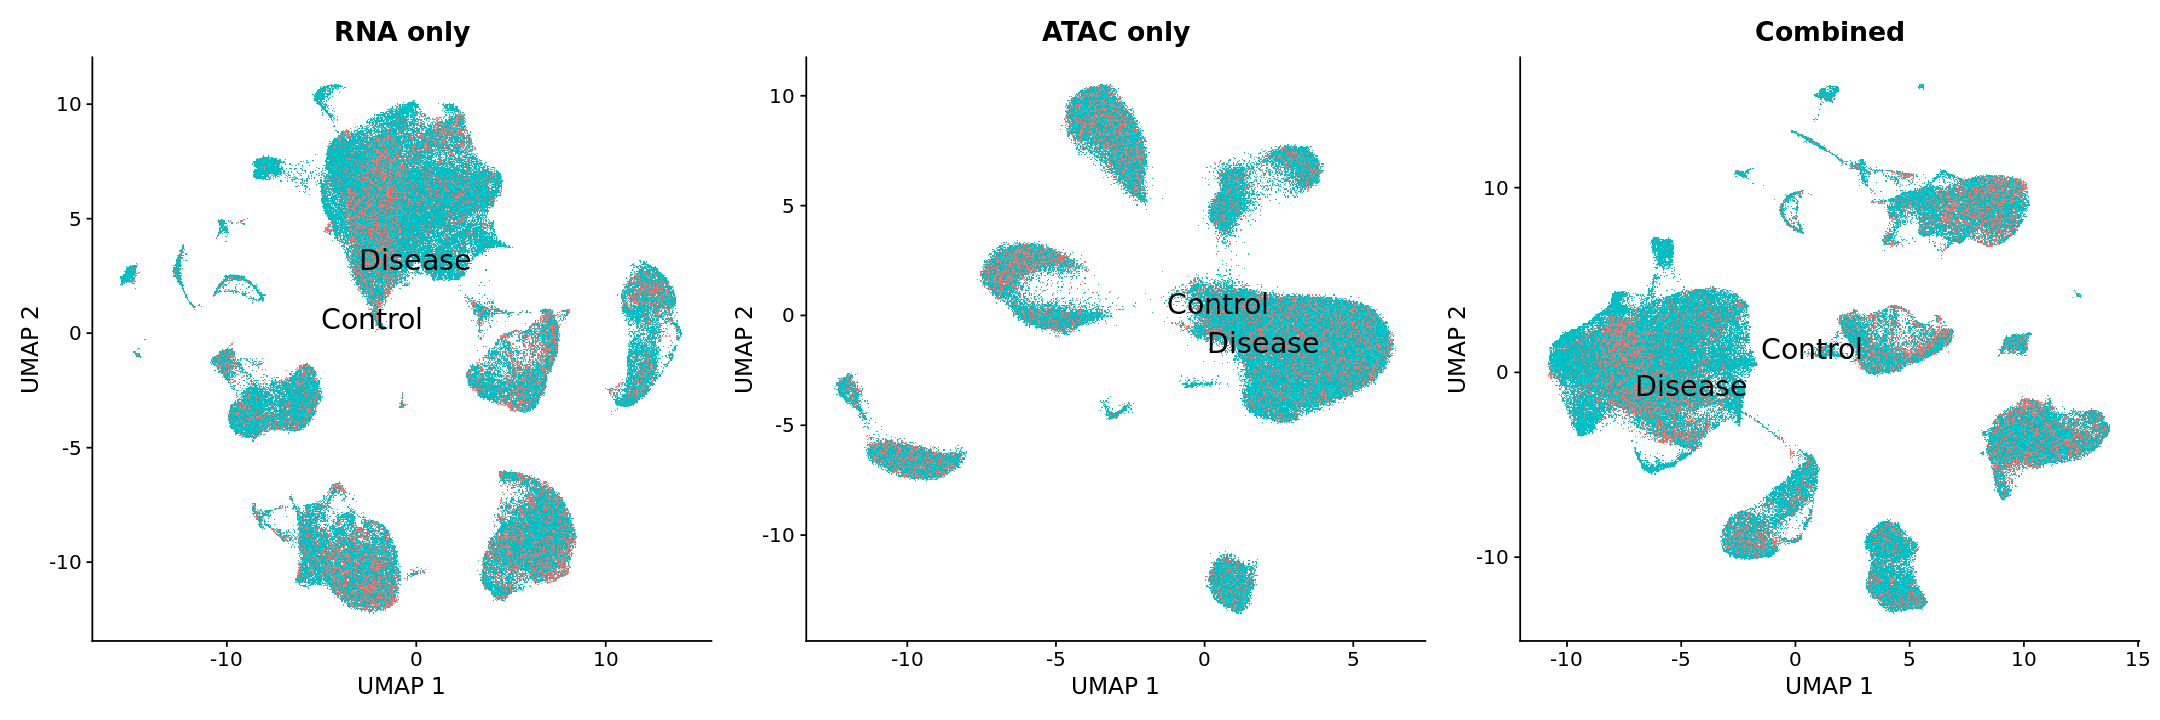

In [15]:
#CHANGE NOTHING
#Making UMAPs that are colored by disease_status (disease or control). 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

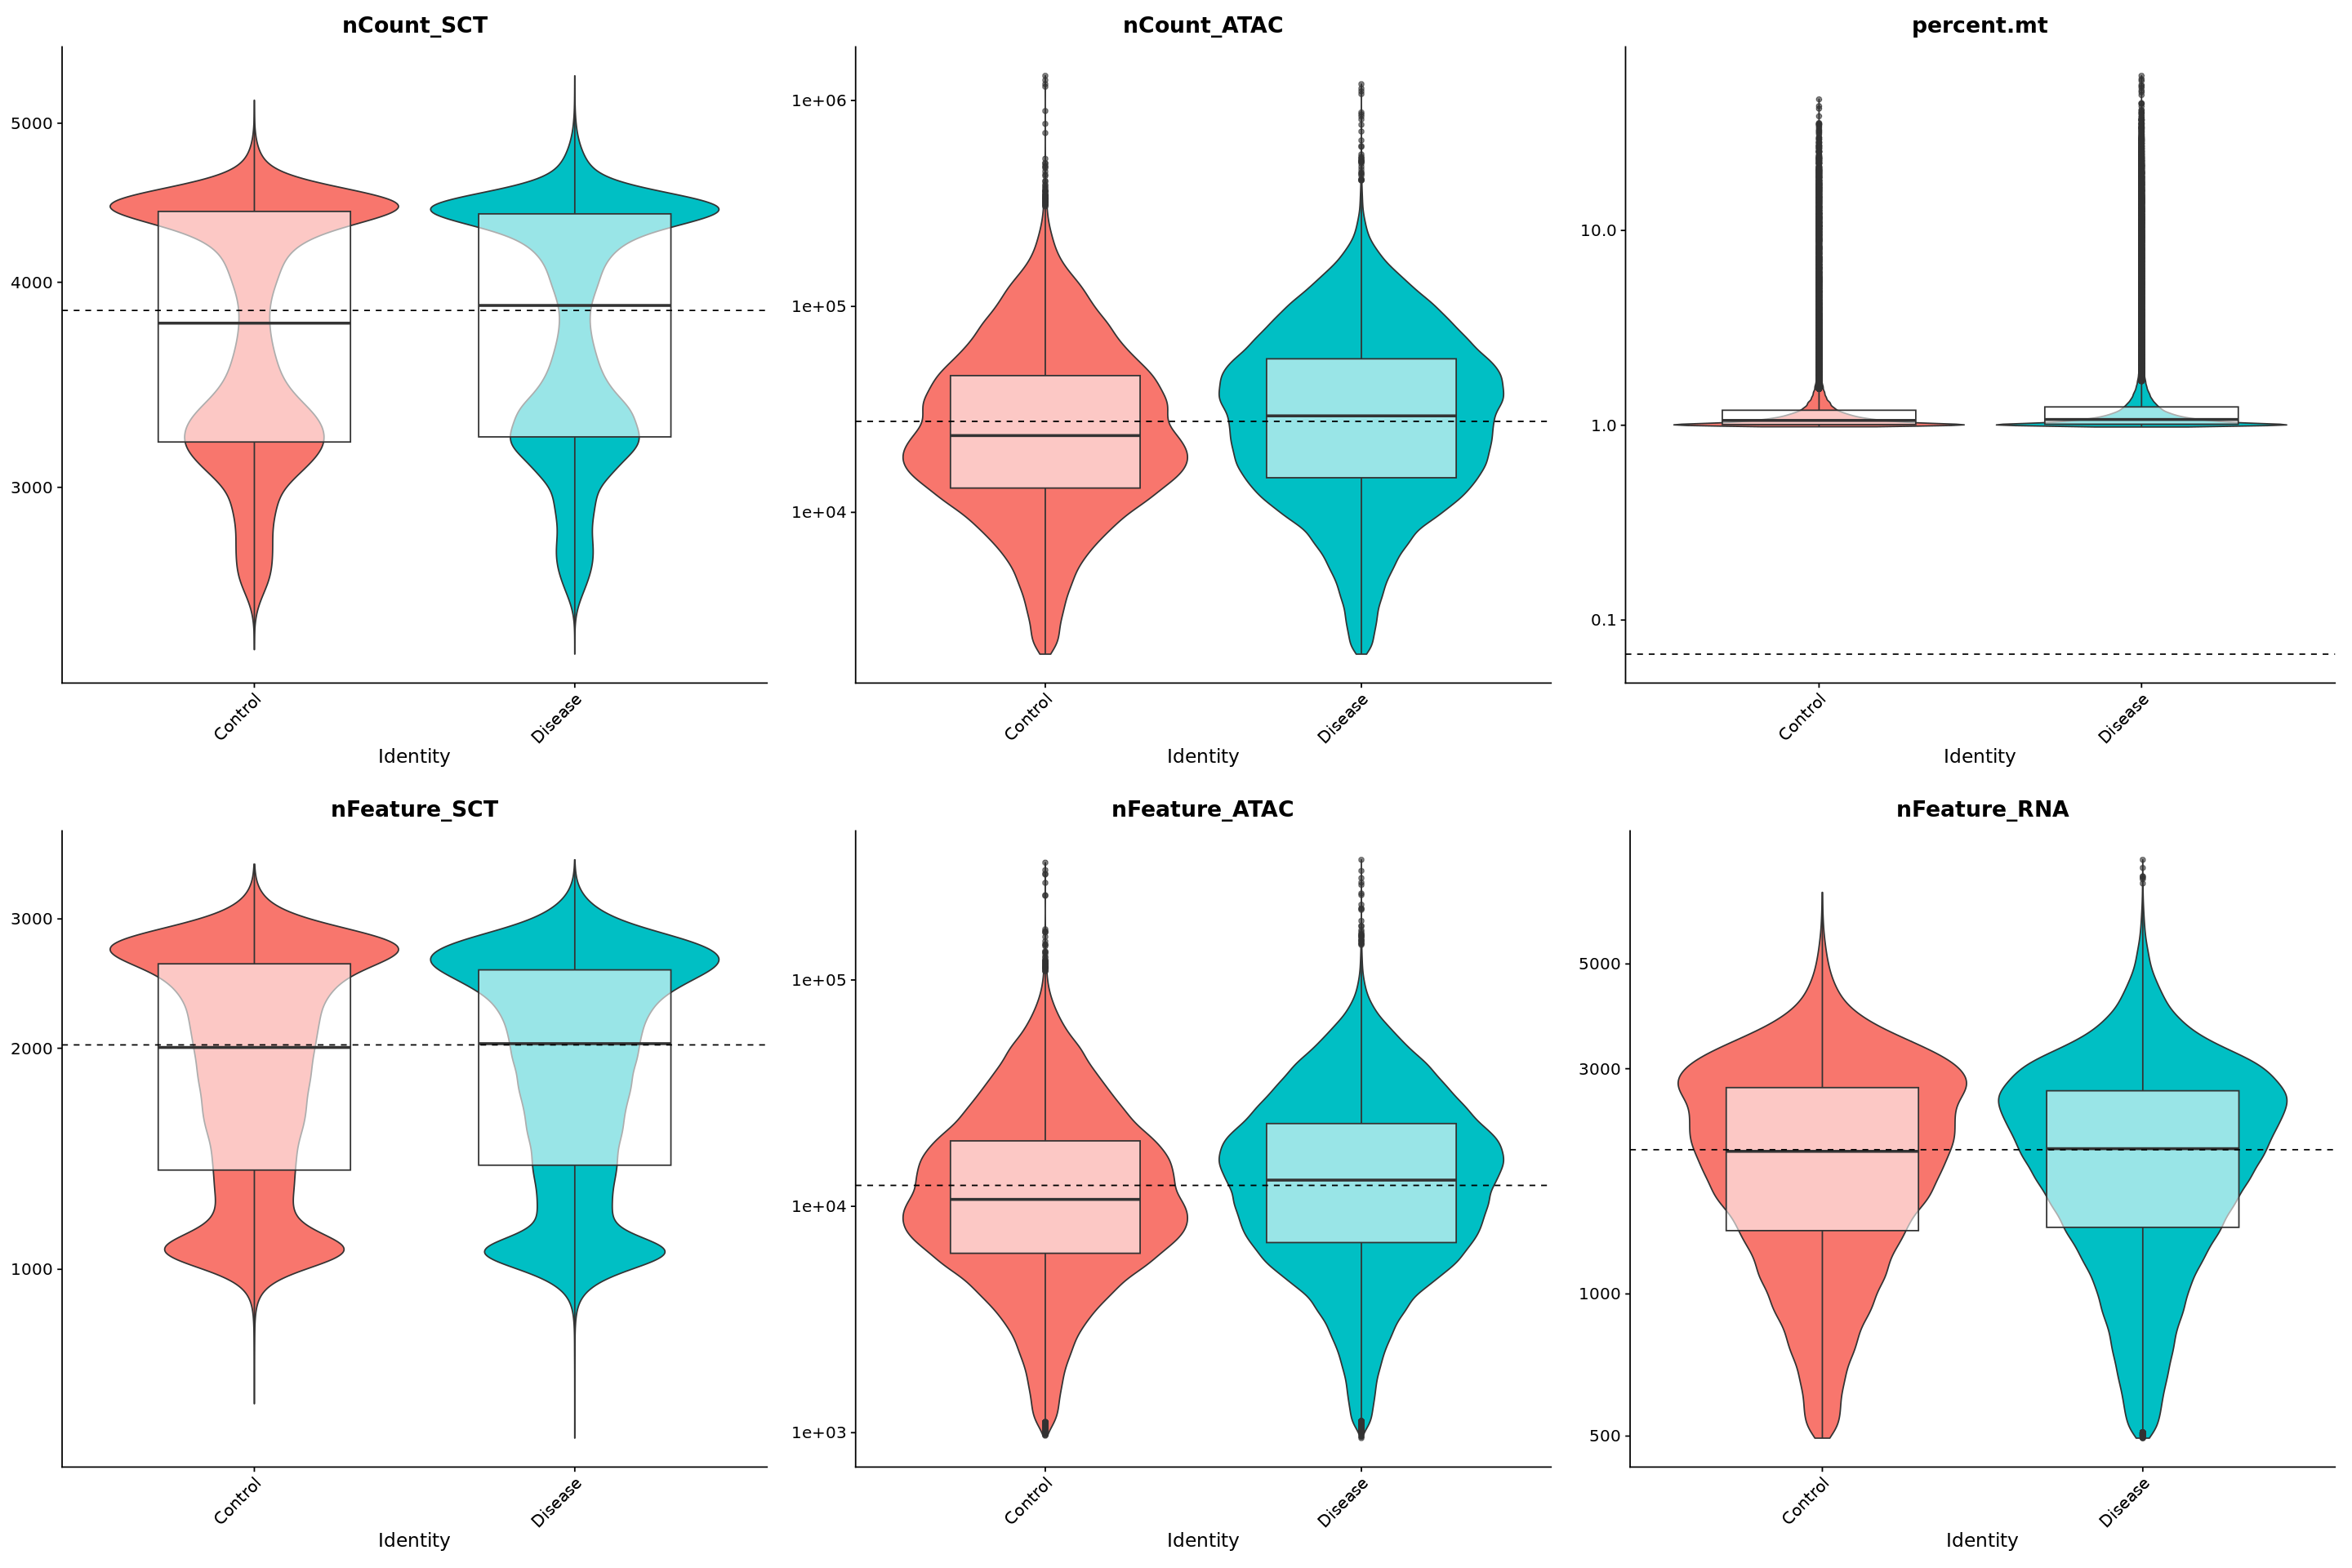

In [17]:
#CHANGE NOTHING HERE 
#Making violin plots colored by disease_status (Control or Disease) 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='disease_status', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



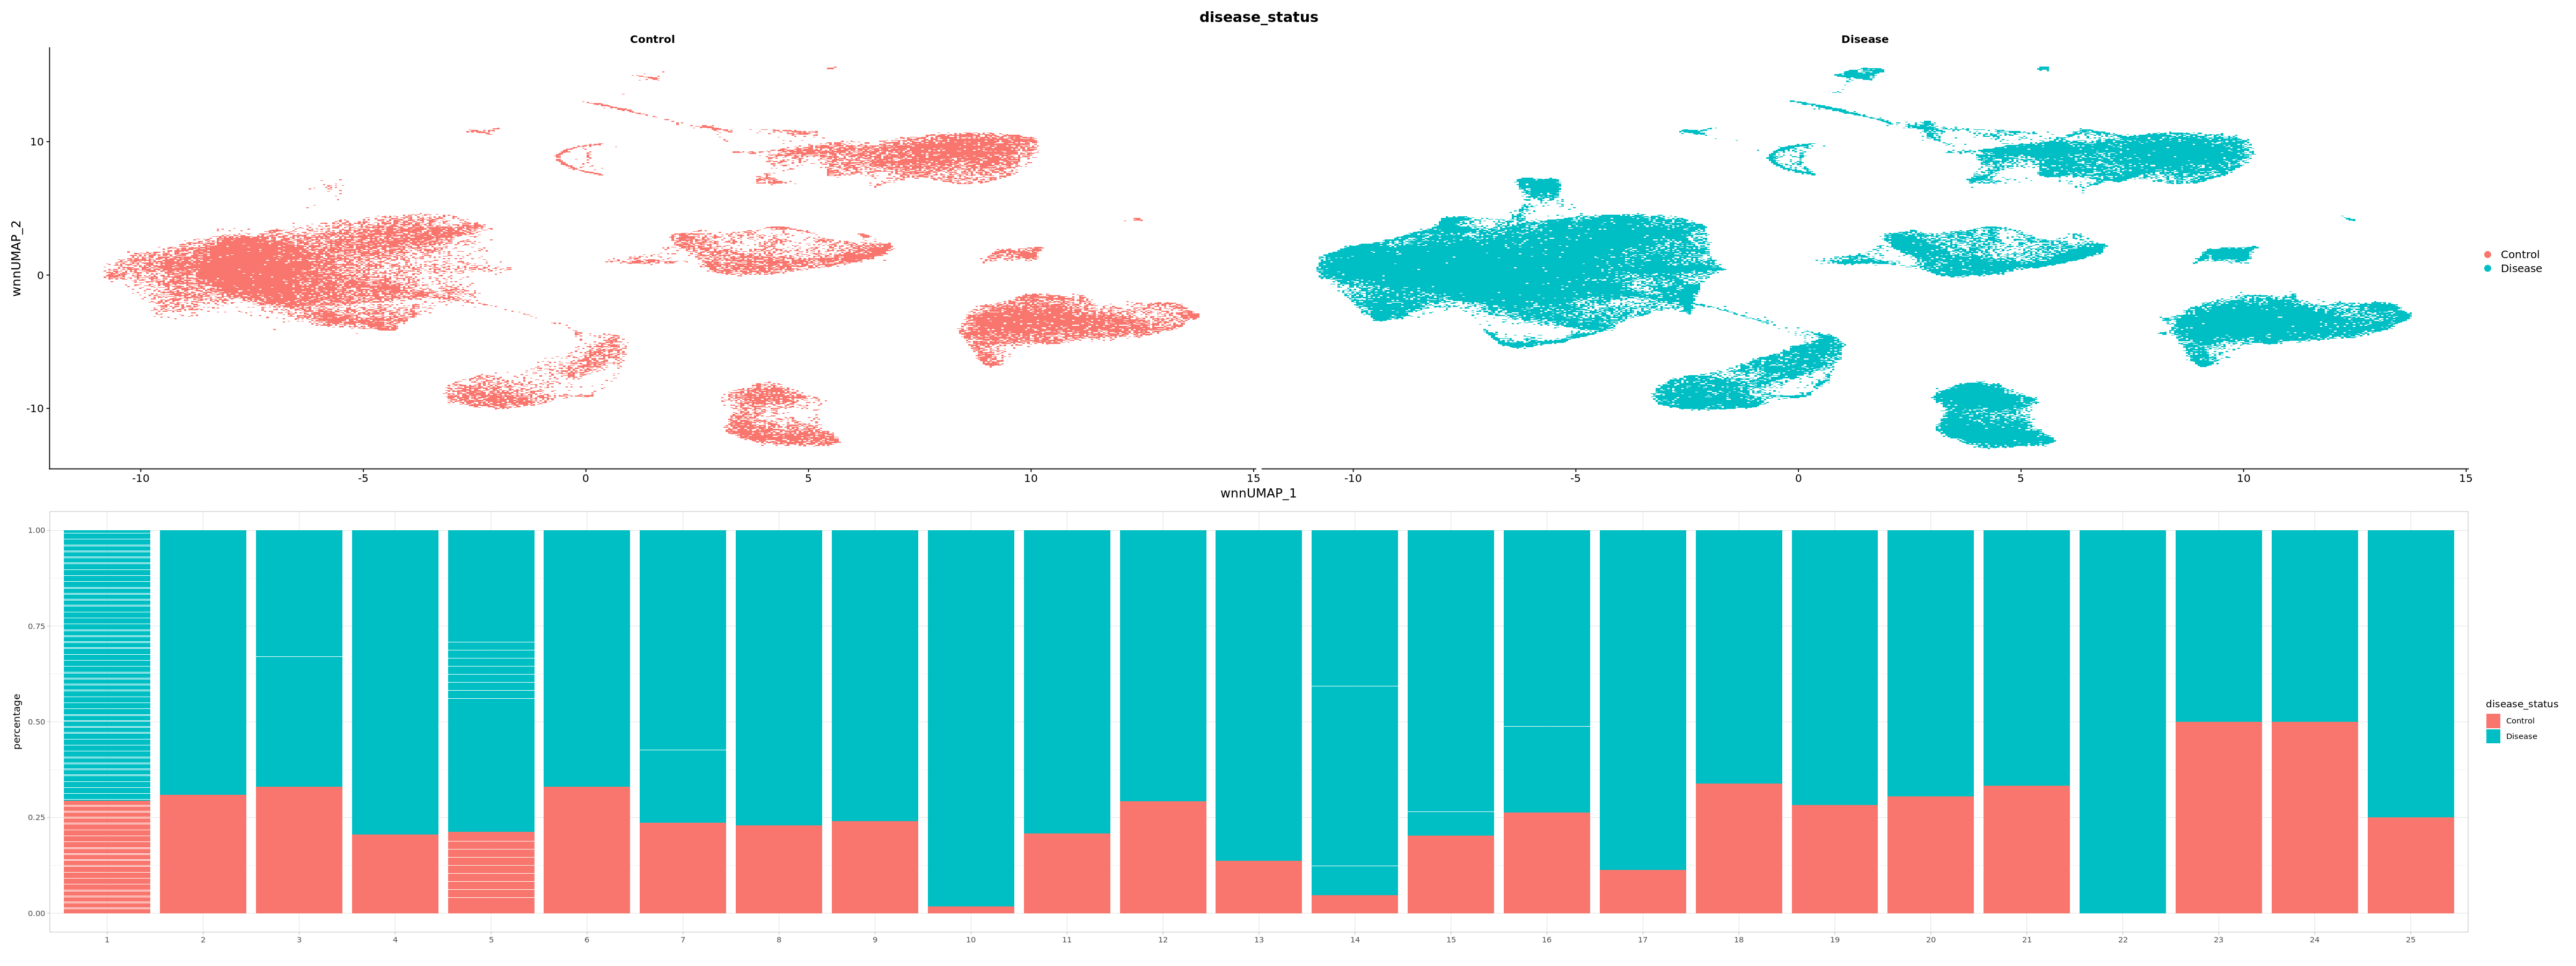

In [19]:
 
options(repr.plot.width=40, repr.plot.height=15)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='disease_status', split.by='disease_status', label=FALSE, label.size=10, repel=TRUE)
adata$value <- 1
p2 <- ggplot(adata[[]], aes(fill=disease_status, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p1 / p2

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



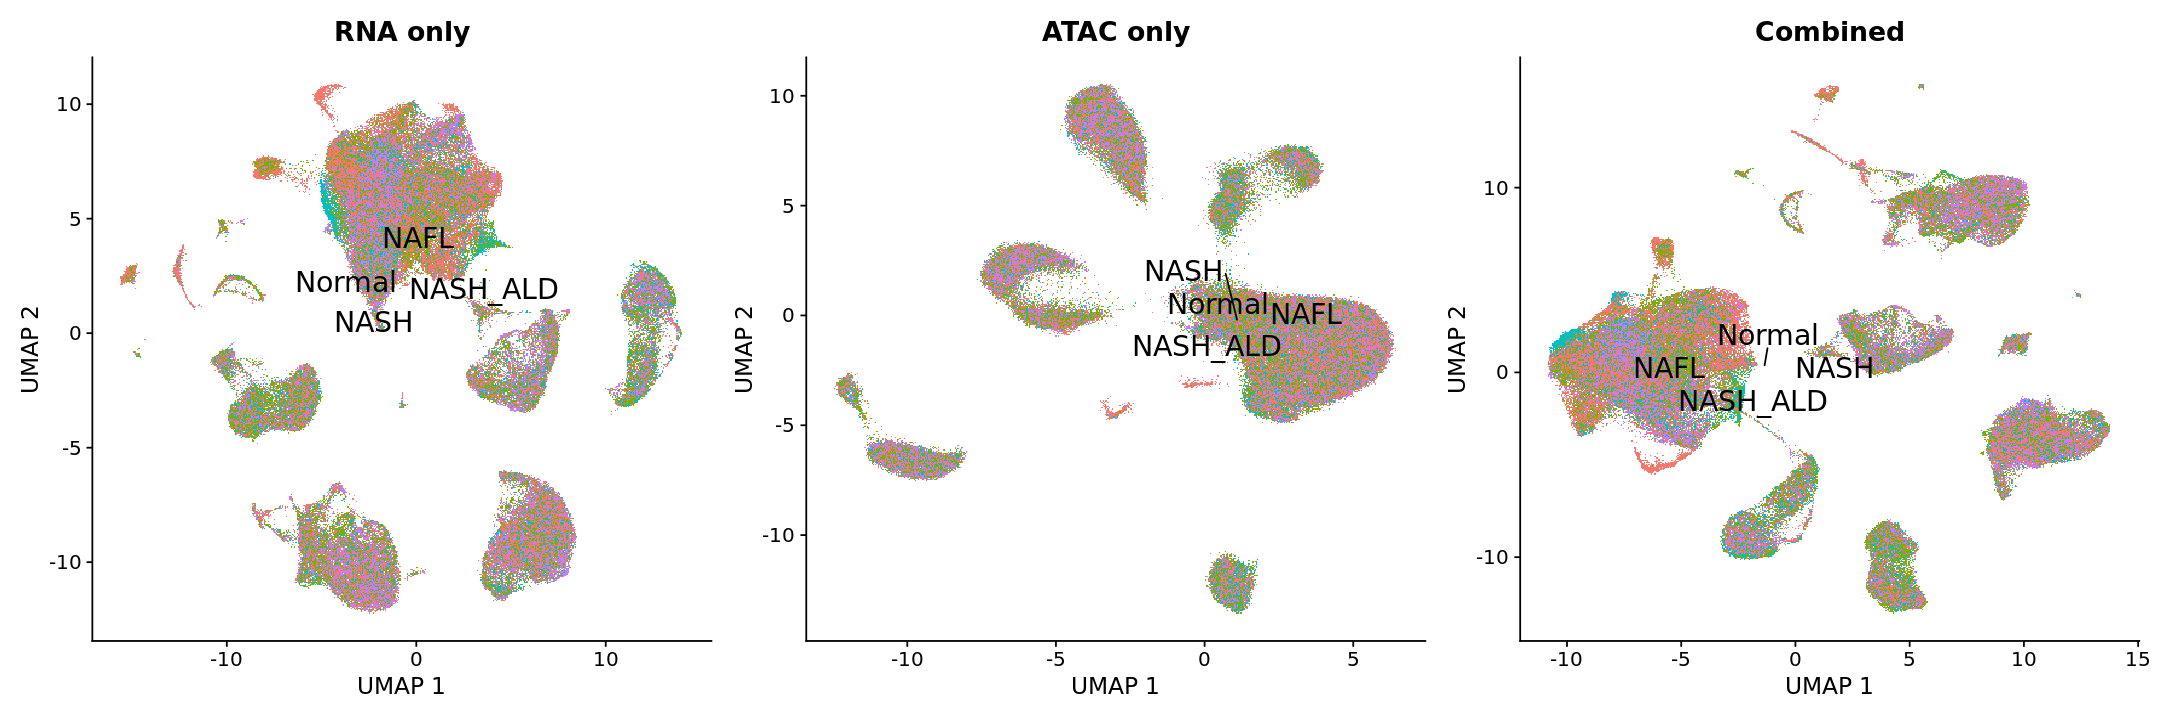

In [16]:
#CHANGE NOTHING
#Making UMAPs that are colored by condition (Normal, NAFL, NASH, NASH_ALD). 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

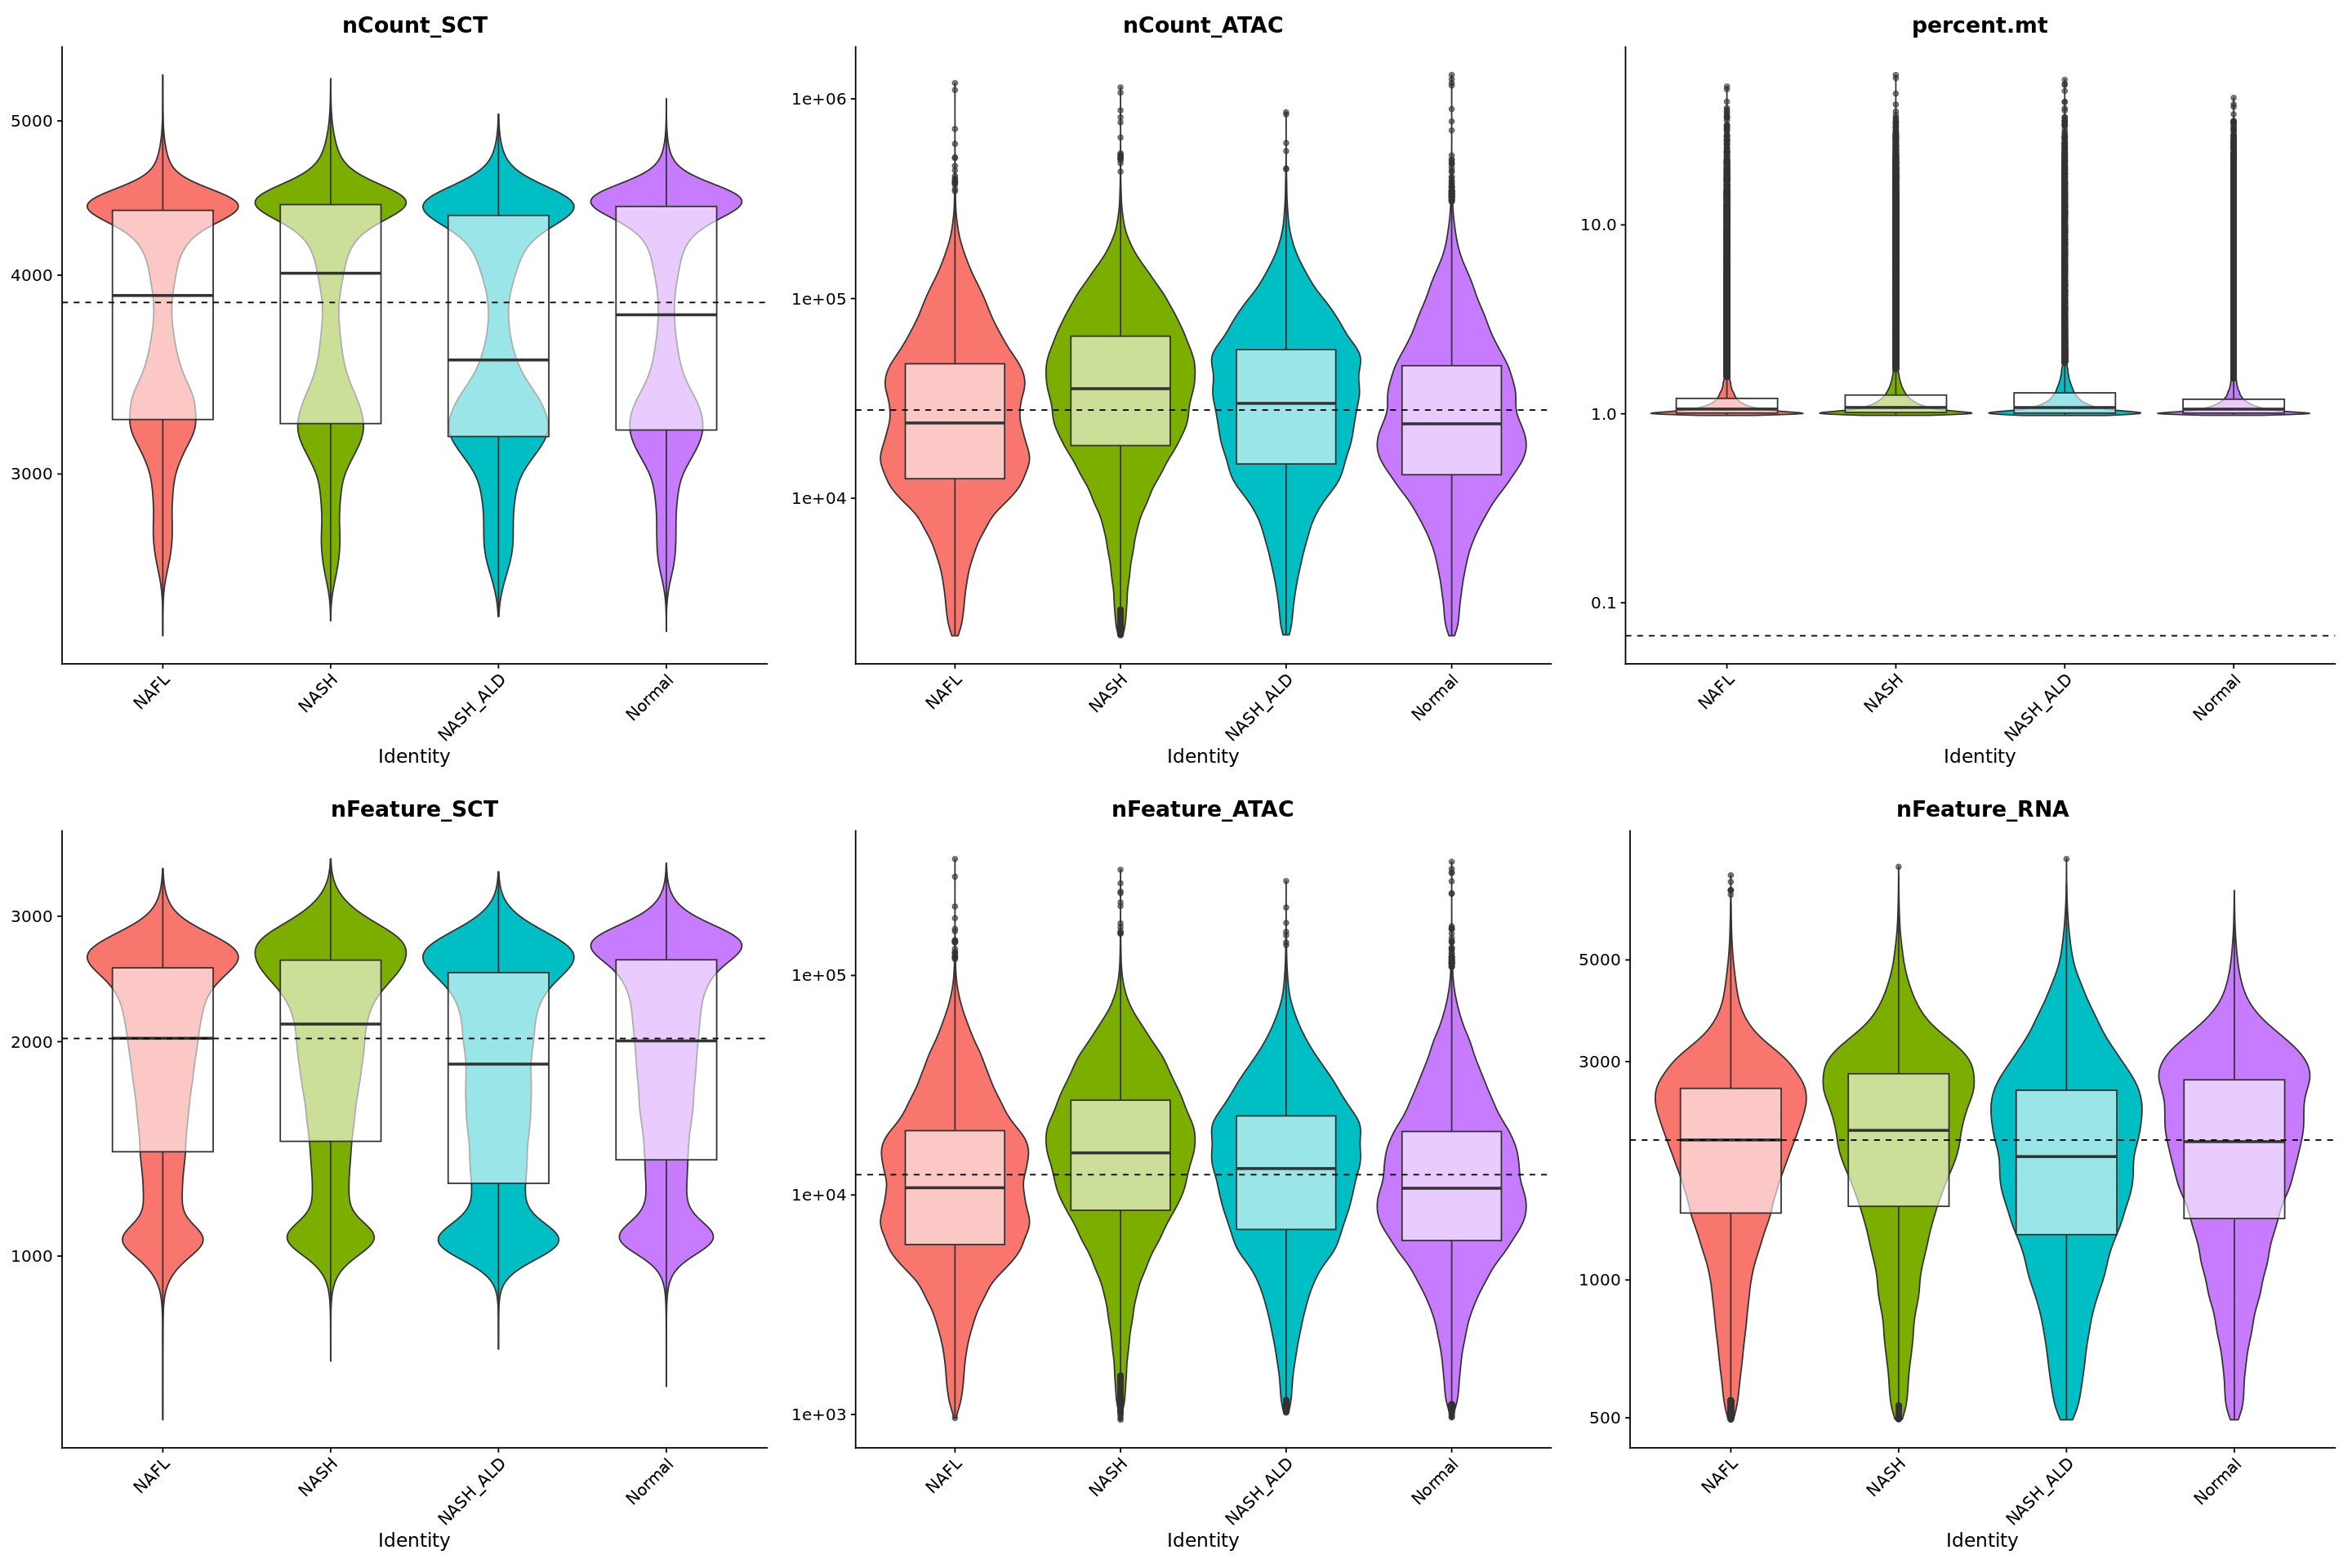

In [18]:
#CHANGE NOTHING HERE 
#Making violin plots colored by condition (Normal, NAFL, NASH, NASH_ALD) 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='condition', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



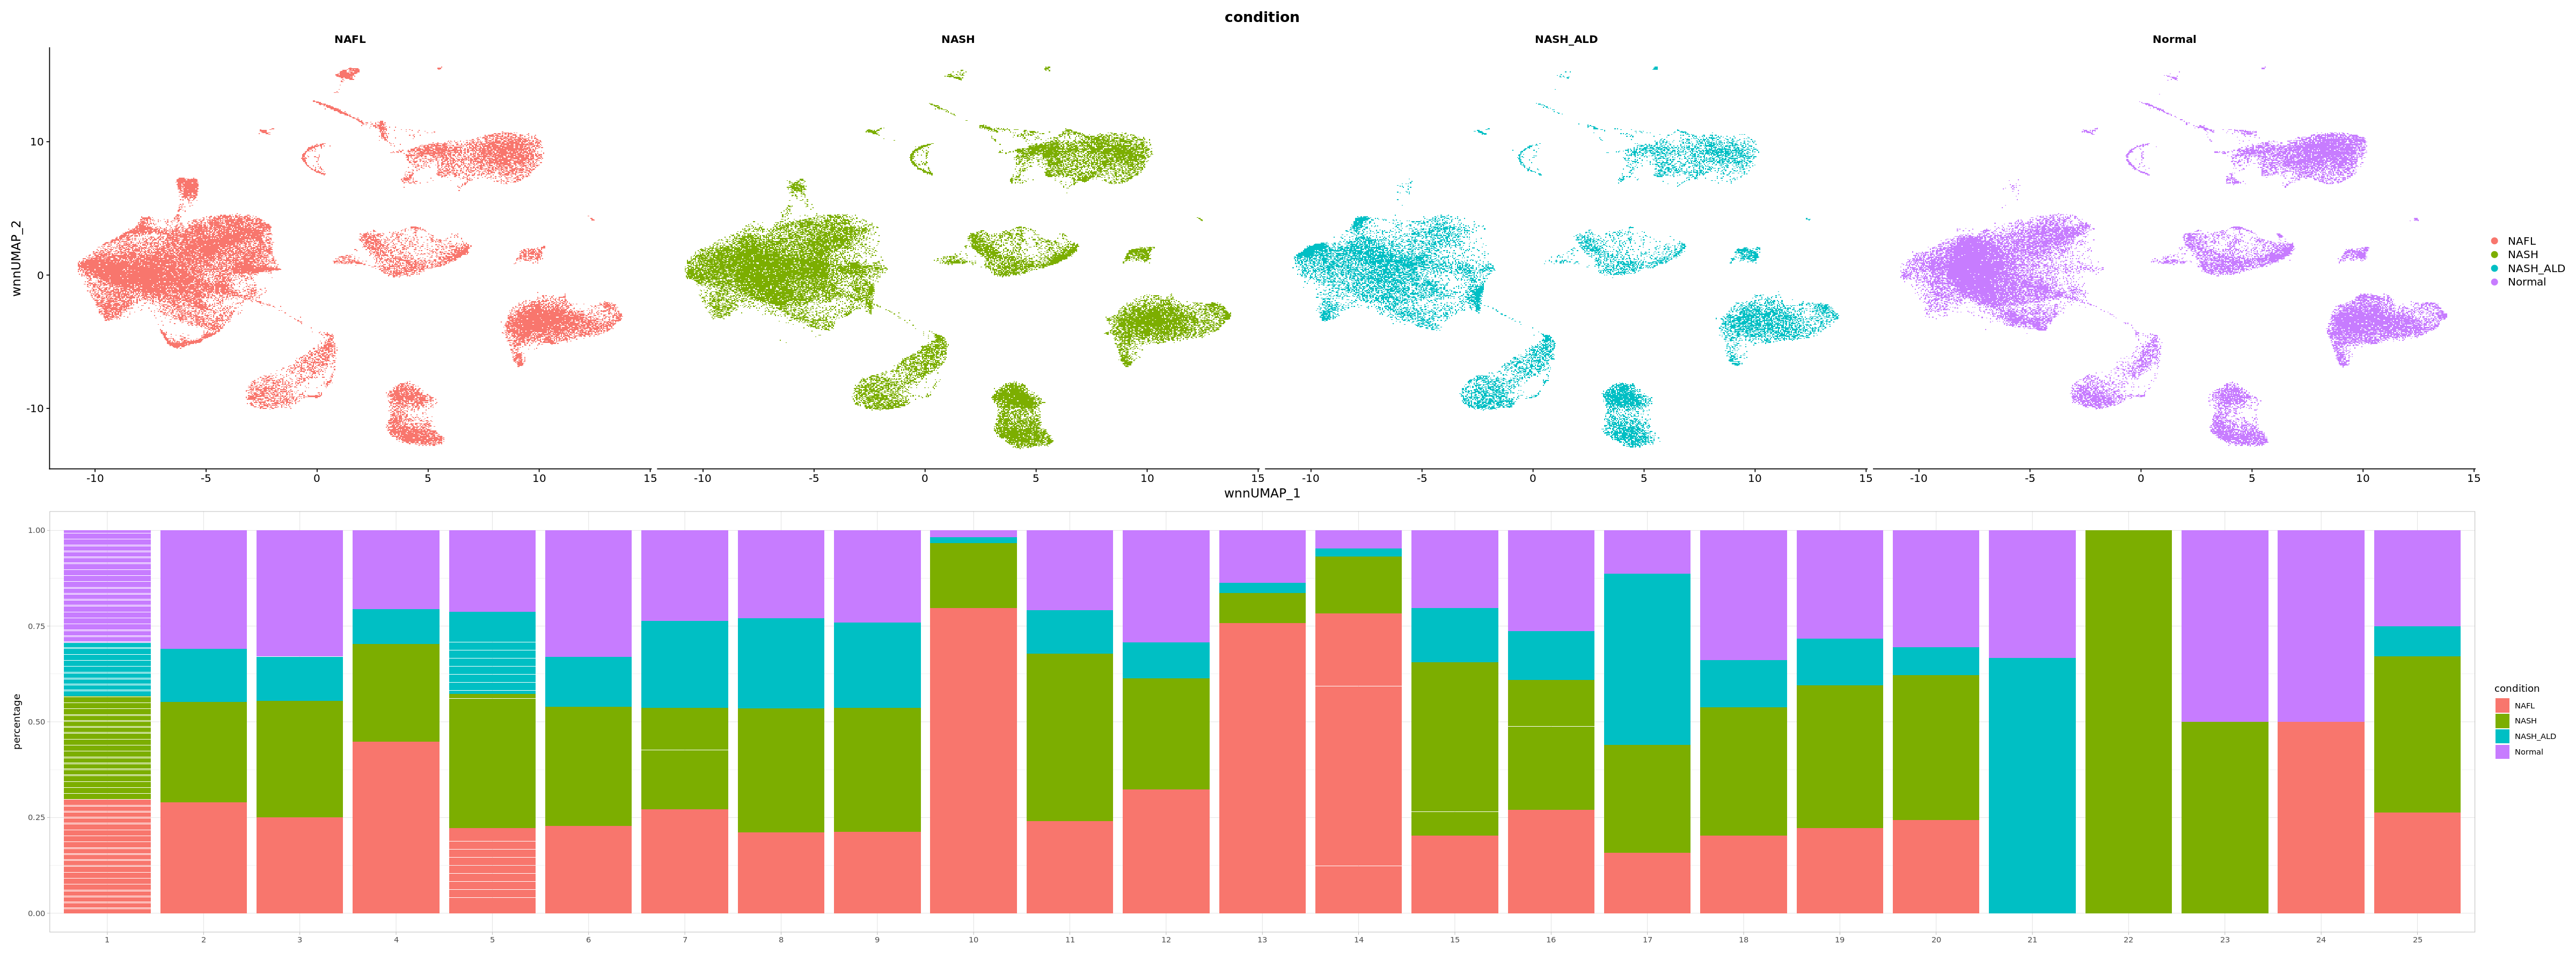

In [20]:
options(repr.plot.width=40, repr.plot.height=15)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='condition', split.by='condition', label=FALSE, label.size=10, repel=TRUE)
adata$value <- 1
p2 <- ggplot(adata[[]], aes(fill=condition, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p1 / p2

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by lane. 
#Interpretation: if any of them are far from the others. 
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='lane', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE -- but changing some numbers to make the plots more readable, trial  
#Making violin plots colored by donor 
#Interpretation: if any of them are far from the others.
options(repr.plot.width=25, repr.plot.height=30)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2) + theme(axis.text = element_text(size = 15))
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='donor_demux', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p2 & NoLegend(), p3 & NoLegend(), p4 & NoLegend(), p5 & NoLegend(), p6 & NoLegend(), ncol = 1, nrow = 6)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by seurat clusters  
#Interpretation: we want these to be distinct from each other because theoretically they are different cell types/populations. So more variability is okay.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='seurat_clusters', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#CHANGE NOTHING HERE 
#Making violin plots colored by pooling batch   
#Interpretation: Ideally we do not want much variability by pooling batch.
options(repr.plot.width=24, repr.plot.height=16)
p1 <- VlnPlot(adata, features='nCount_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_SCT), linetype='dashed', lw=2)
p2 <- VlnPlot(adata, features='nFeature_SCT', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
p3 <- VlnPlot(adata, features='nCount_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nCount_ATAC), linetype='dashed', lw=2)
p4 <- VlnPlot(adata, features='nFeature_ATAC', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_ATAC), linetype='dashed', lw=2)
p5 <- VlnPlot(adata, features='percent.mt', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$percent.mt), linetype='dashed', lw=2)
p6 <- VlnPlot(adata, features='nFeature_RNA', group.by='batch', pt.size=0, log=TRUE) + geom_boxplot(width=.6, fill='white', alpha=.6, pt.size=0) + geom_hline(yintercept=median(adata$nFeature_SCT), linetype='dashed', lw=2)
# p1 / p2 
# p3 / p4 
# p5 / p6

figure <- ggarrange(p1 & NoLegend(), p3 & NoLegend(), p5 & NoLegend(), p2 & NoLegend(), p4 & NoLegend(), p6 & NoLegend(), ncol = 3, nrow = 2)
figure

In [ ]:
#Note to SIERRA, might need to edit this to include batch...??? Ask Rebecca 
options(repr.plot.width=40, repr.plot.height=15)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='donor_demux', split.by='donor_demux', label=FALSE, label.size=10, repel=TRUE)
adata$value <- 1
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p1 / p2

In [ ]:
options(repr.plot.width=20, repr.plot.height=5)
p2 <- ggplot(adata[[]], aes(fill=donor_demux, y=value, x=seurat_clusters)) + geom_bar(position=position_fill(reverse=TRUE), stat='identity') + xlab('') + ylab('percentage') + theme_light()
p2

In [ ]:
table(adata$seurat_clusters, adata$donor_demux)

In [ ]:
adata$donor_demux

In [ ]:
saveRDS(adata,'/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_DonorDemuxAndPoolingBatch.rds')

# Reading in disease status to color the clusters by disease status
#### Reading in disease status to the metadata of the rds batch corrected for donor and pooling batch. 

In [8]:
#remember to run the first 3 blocks of code first! 
#this will read in the merged seurat object w 50k HVWs, that has been batch corrected for donor and pool. 
adata<-readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_DonorDemuxAndPoolingBatch.rds')



In [9]:
#adding additional metadata and calling it meta
#includes "donor", "condition", "additional", and "disease_status"
#not working LUCA
meta<-read.table("/nfs/lab/scorban/fnih_liver_231110/multiome_metadata.txt", sep = "\t", header = TRUE)



In [10]:
#Add in condition to the current metadata 
#not working LUCA
adata@meta.data$condition <- meta$condition[match(adata@meta.data$donor_demux, meta$donor)]



In [11]:
#Add in disease_status to the current metadata 
#not working LUCA
adata@meta.data$disease_status <- meta$disease_status[match(adata@meta.data$donor_demux, meta$donor)]



In [12]:
unique(adata@meta.data$disease_status)

[1] "Disease" "Control"

In [13]:
unique(adata@meta.data$condition)

[1] "NAFL"     "NASH"     "Normal"   "NASH_ALD"

In [14]:
head(adata@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,nCount_ATAC,nFeature_ATAC,donor_demux,nCount_SCT,⋯,log_nFeature_SCT,lane,batch,nCount_windows,nFeature_windows,windows.weight,wsnn_res.0.25,value,condition,disease_status
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<chr>,<chr>
MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1,SeuratProject,1629,1173,0.06138735,1644,1185,107621,39944,HL160042,3041,⋯,7.098376,MM_1341_1_2_MM_1337_1_2,firstPR,18689,5909,0.00423659,2,1,NAFL,Disease
MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1,SeuratProject,8957,3860,0.00000000,9176,3955,10345,4931,HL190326,4596,⋯,8.049427,MM_1341_1_2_MM_1337_1_2,firstPR,3543,1617,0.19094990,4,1,NAFL,Disease
MM_1341_1_2_MM_1337_1_2_AAACAGCCAGTTATGT-1,SeuratProject,9791,3730,0.00000000,10043,3858,34807,13601,HL170046,4444,⋯,7.971086,MM_1341_1_2_MM_1337_1_2,firstPR,13964,4861,0.17996294,1,1,NASH,Disease
MM_1341_1_2_MM_1337_1_2_AAACAGCCATCGTTCT-1,SeuratProject,3222,1911,0.06207325,3270,1938,51803,20677,HL190326,3447,⋯,7.555382,MM_1341_1_2_MM_1337_1_2,firstPR,18888,6538,0.29904601,1,1,NAFL,Disease
MM_1341_1_2_MM_1337_1_2_AAACAGCCATGGCCTG-1,SeuratProject,2806,1670,0.03563792,2844,1689,36761,14630,HL160029,3275,⋯,7.420579,MM_1341_1_2_MM_1337_1_2,firstPR,7181,2558,0.26061168,2,1,Normal,Control
MM_1341_1_2_MM_1337_1_2_AAACAGCCATGTTGGC-1,SeuratProject,6370,2897,0.00000000,6506,2984,46478,18548,HL170060,4523,⋯,7.948385,MM_1341_1_2_MM_1337_1_2,firstPR,16061,5729,0.45175126,1,1,NASH_ALD,Disease


# Trying FindAllMarkers
### Installing DEseq2, and trying to run FindAllMarkers on RNA using DEseq2 as the test.use. 

In [ ]:
#Installing DEseq2 
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2")

In [ ]:
R.Version()

In [ ]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install(version = "3.16")

In [ ]:
BiocManager::install("DESeq2")

In [ ]:
system.file(package='DESeq2')

In [ ]:
install.packages('DESeq2')

In [4]:
#reading in the merged seurat object, batch corrected for donor and pooling batch 
#could not figure out DESeq, so will be running FindAllMarkers using standard wilcoxx 
adata<-readRDS('/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_DonorDemuxAndPoolingBatch.rds')

In [5]:
all.markers <- FindAllMarkers(object = adata, assay = 'RNA')
head(x = all.markers)

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20

Calculating cluster 21

Calculating cluster 22

Calculating cluster 23

Calculating cluster 24

Calculating cluster 25



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
CRP,0,2.087685,0.686,0.201,0,1,CRP
FGB,0,2.057525,0.942,0.386,0,1,FGB
FGL1,0,1.921266,0.957,0.339,0,1,FGL1
FGG,0,1.873444,0.915,0.357,0,1,FGG
SAA2,0,1.826379,0.718,0.334,0,1,SAA2
HAL,0,1.804398,0.731,0.155,0,1,HAL


In [6]:
#Saving the above output as a csv file. 
write.csv(all.markers, '/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_DonorDemuxAndPoolingBatch_020624_FindAllMarkers.csv', quote=FALSE)

In [7]:
#Saving above output as an RDS, because I'm not certain what is most useful to save as, and it took forever to run, and I don't want to lose anything...
saveRDS(all.markers, '/nfs/lab/scorban/fnih_liver_231110/intregration/Jan23_2024_seuratintegration_4LaneAnd8LaneMerged_40donorstotal/012324_fnih_liver_40donormerged_50kHVWs_HarmonyCovariates_DonorDemuxAndPoolingBatch_020624_FindAllMarkers.rds')

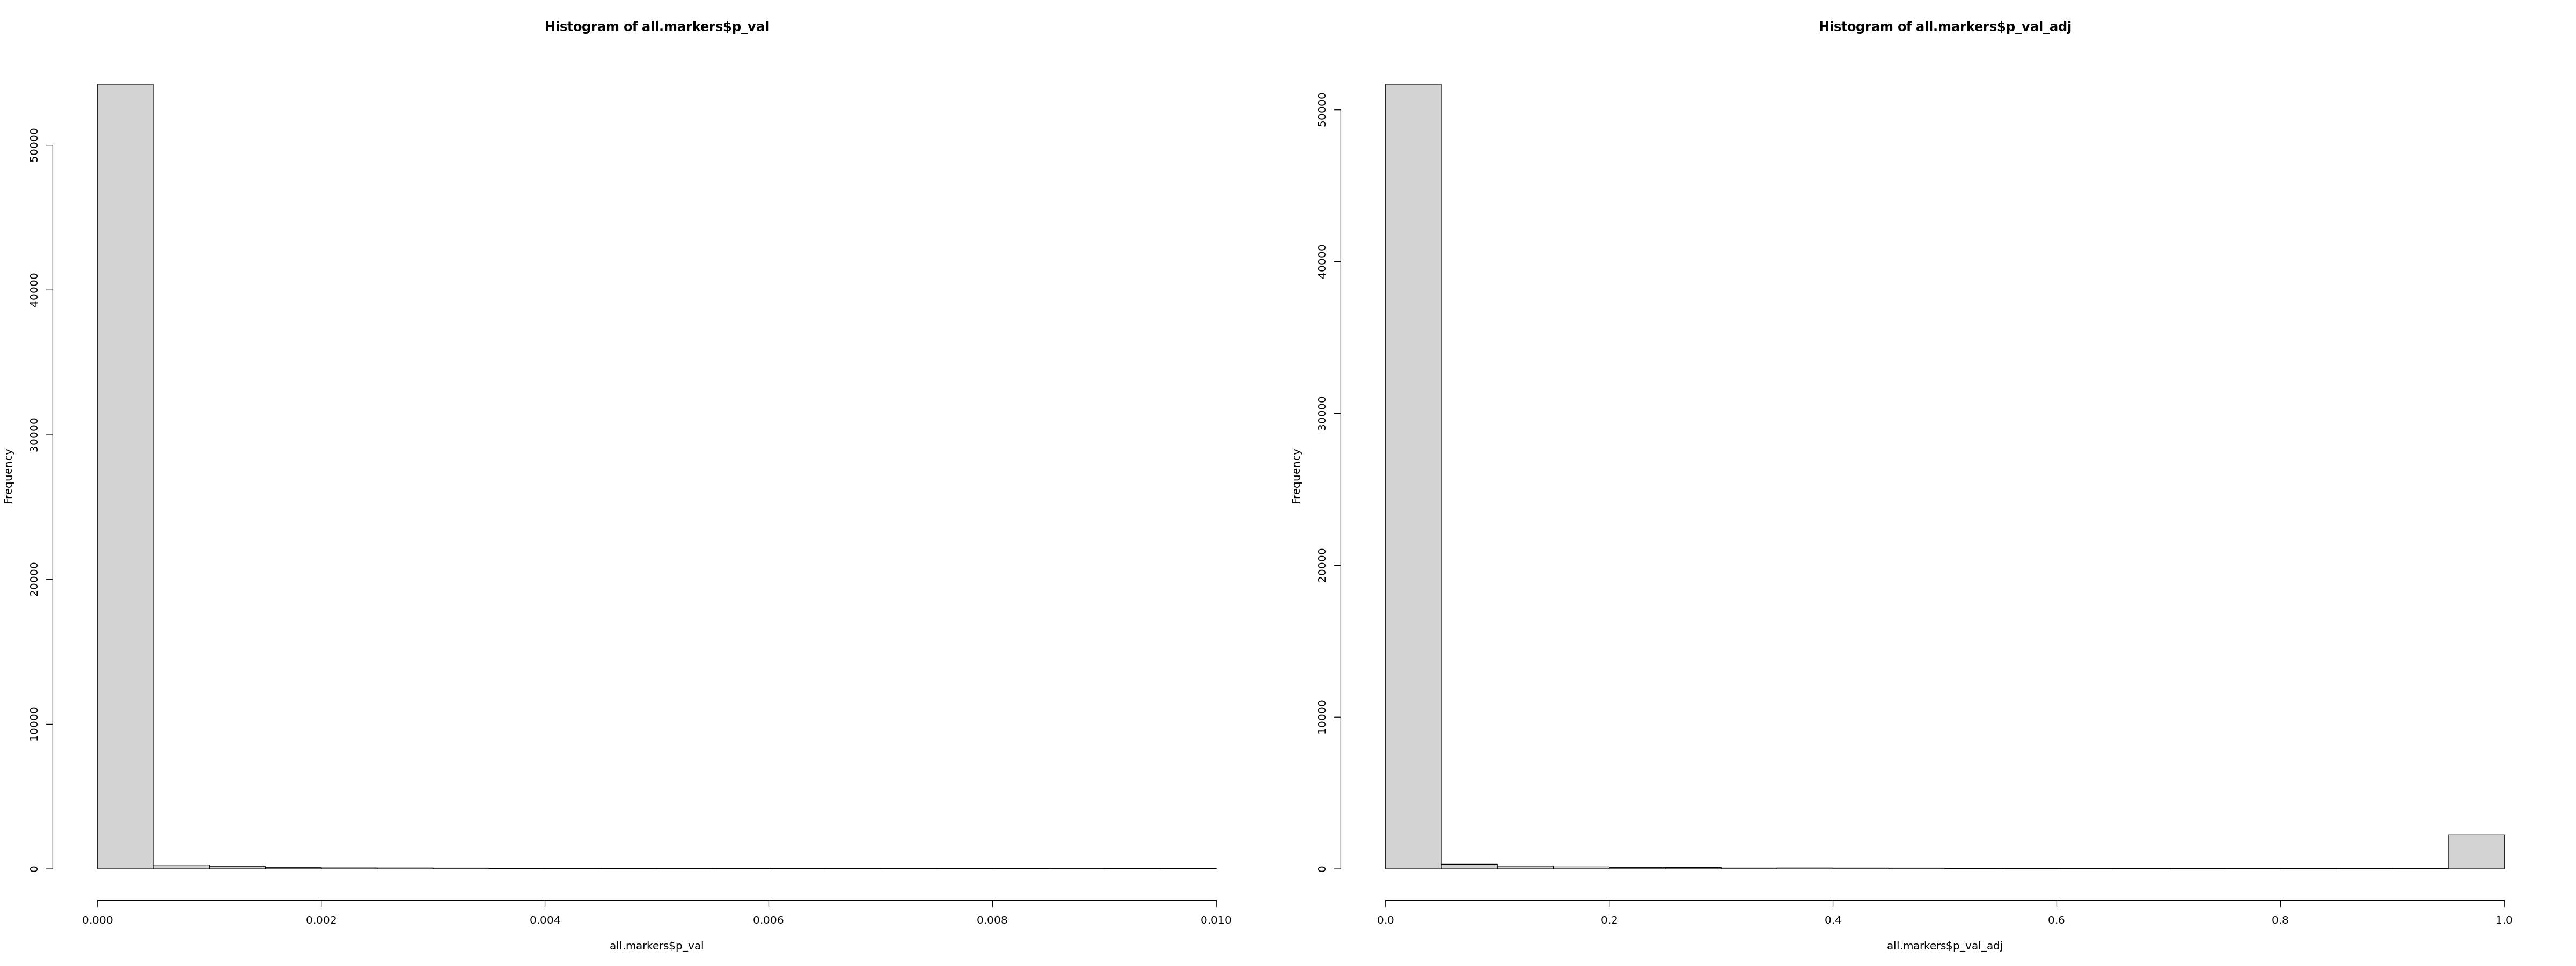

In [23]:
#plat the distribution of p-values 
#notes, the FindAllMarkers code filters down to significant results already 
par(mfrow=c(1,2)) #puts them in two columns 
hist(all.markers$p_val)

hist(all.markers$p_val_adj)

In [24]:
#looking at how many rows and columns are in the table 
dim(all.markers)


[1] 55270     7

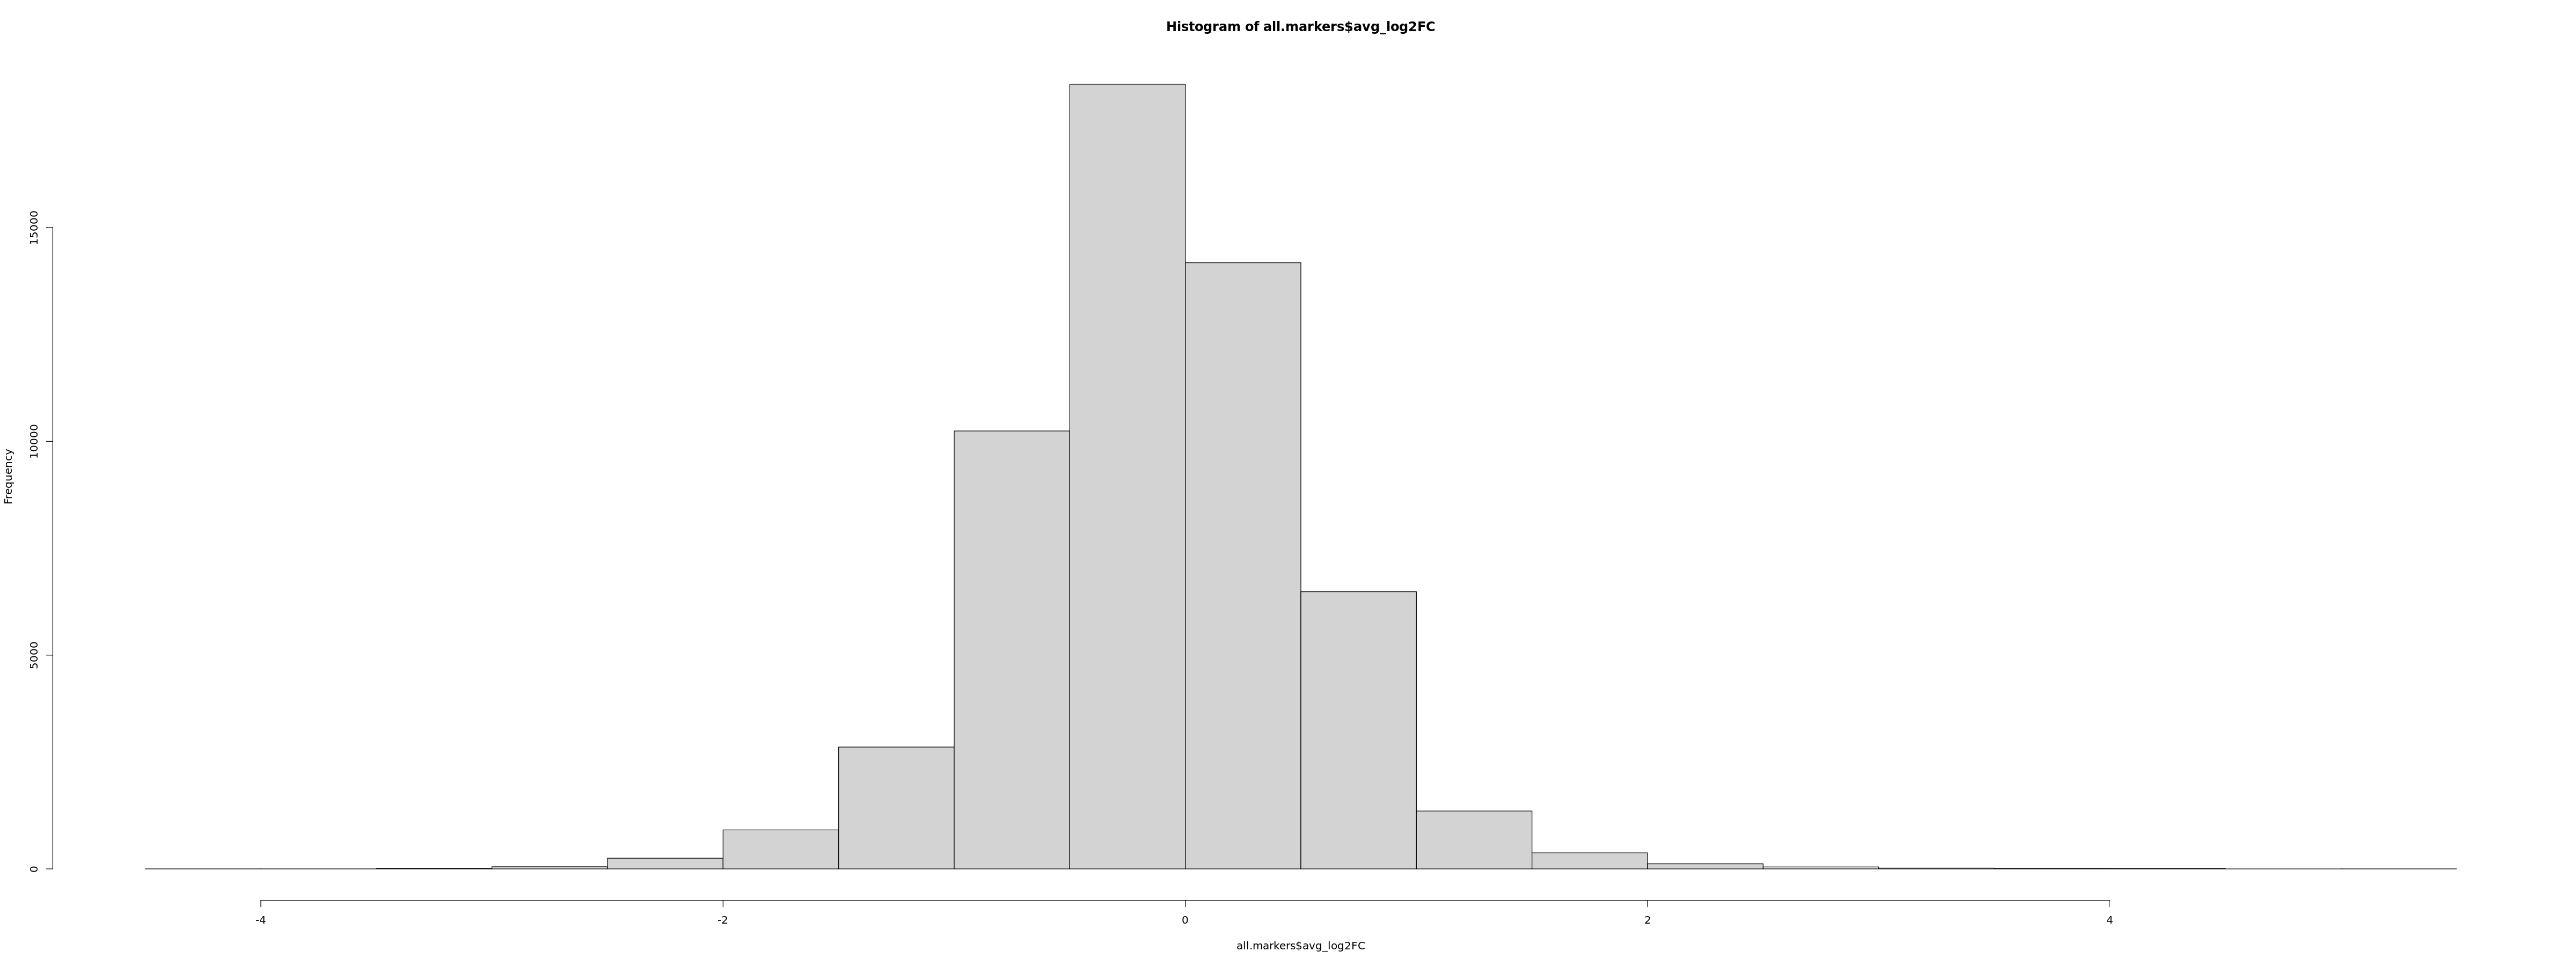

In [25]:
#ploting the fold change 
hist(all.markers$avg_log2FC)

In [ ]:
#calculate a rank value (the negative log 10 p-val multiplied by the fold change. Scales fold change by significance.)
#take the smallest non-zero number and use that, because it errors with a 0 p-val. 

In [26]:
#Look at distribution of results by cluster
table(all.markers$cluster)




   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
2293 2529 2797 1931 2790 3633 2180 2144 3007 2078 2666 2016 2628 2539 2985 2822 
  17   18   19   20   21   22   23   24   25 
2430 2819 2878 3702  605    0    0    0 1798 

In [ ]:
#split the data frame by cluster
#pick a cluster of interest, write the code for that, then for loop the others. 
#cluster results sorted by rank value 
#gene set enrichment (fgsea package - takes a rank value for all of the genes, note you can run it on only significant results, but might be better on all results)
##fgsea will give a list of pathways that are enriched, this can be cell types, disease relevant, and if there are donor specific clusters it will highlight what is awk about that donor possibly


In [ ]:
#Notes from Hannah 
#plot the distribution of p-values 

In [ ]:
adata <- readRDS('101523_fNIH_liver_merge_correctDemux.rds')
adata

In [ ]:
x <- table(adata$donor_demux, adata$lane)

In [ ]:
write.table(x,"liver_donorbylane_cellcount.txt", sep='\t', quote = FALSE, col.names = TRUE)

In [ ]:
meanGenes <- mean(adata@meta.data$nFeature_RNA)
meanReads <- mean(adata@meta.data$nCount_RNA)
meanFrag  <- mean(adata@meta.data$nCount_ATAC)
meanFrag2 <- mean(adata@meta.data$nCount_ATAC)

meanGenes
meanReads
meanFrag 
meanFrag2

In [ ]:
adata

In [ ]:
print(nrow(adata@meta.data))
   # print(mean(adata@meta.data$nFeature_RNA))
print(mean(adata@meta.data$nCount_RNA))
print(mean(adata@meta.data$nFeature_RNA))

print(mean(adata@meta.data$nCount_ATAC))
print(nrow(adata@meta.data)/16)
print(nrow(adata@meta.data)/4)

In [ ]:
for (SAMPLE in samples){
    print(paste0("starting: ",SAMPLE))
### cellranger output directory
    wd <-sprintf('/nfs/lab/projects/nash_nafld_liver/counts/%s/outs/',SAMPLE)
## directory to store plots 
    plots_dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s',SAMPLE)
### directory to store results
    output_dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/rscript2outs',SAMPLE)
    dir.create(output_dir)
print(paste0("loading intermediate object: ",SAMPLE))
### Read in object from R script #1
    adata <- readRDS(sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/intermediate_filtered.rds',SAMPLE))
# RNA analysis
    DefaultAssay(adata) <- 'RNA'
    adata <- SCTransform(adata, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
    
# ATAC analysis
# We exclude the first dimension as this is typically correlated with sequencing depth
    DefaultAssay(adata) <- 'ATAC'
    adata <- RunTFIDF(adata)
    adata <- FindTopFeatures(adata, min.cutoff='q0')
    adata <- RunSVD(adata)
    adata <- RunUMAP(adata, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
    
#read in the cellranger output per_barcode_metrics.csv file
    bc_summary_fp = sprintf(paste0(wd,"per_barcode_metrics.csv"))
    bc_summary = read.table(bc_summary_fp, sep=',', header=1)
    bc_summary["new_gex_umis_count"] = bc_summary["gex_exonic_umis"] + bc_summary["gex_intronic_umis"]
    
#plot RNA UMIs (gex_exonic_umis+gex_intronic_umis) per each BC
    options(repr.plot.width=6,repr.plot.height=6)
    bc_summary <- bc_summary[order(bc_summary$new_gex_umis_count, decreasing=TRUE),]
    p1 = plot(bc_summary$new_gex_umis_count, log='xy', type='l', main="RNA UMIs", 
         xlab="BC Rank", ylab="Number RNA UMIs", col='dark green', lwd=2)
    
#plot ATAC UMIs (atac_fragments) per each BC
    bc_summary <- bc_summary[order(bc_summary$atac_fragments, decreasing=TRUE),]
    plot(bc_summary$atac_fragments, log='xy', type='l', main="ATAC UMIs", 
         xlab="BC Rank", ylab="Number ATAC UMIs", col='orange', lwd=2)
    
### Read in Data and Prepare Metadata
    
#get the raw and filtered (by us) RNA counts matrices
#Read in RNA assay counts from our filtered seurat object
    
    DefaultAssay(adata) <- 'RNA'
    toc = GetAssayData(object = adata, slot = "counts")
    
#Read in raw RNA counts from CellRanger outputs
    tod = Seurat::Read10X_h5(file.path(wd, 'raw_feature_bc_matrix.h5'))$`Gene Expression`
    
#pull out the required metadata from the clustered filtered adata object
#we need the UMAP coordinates (RD1 and RD2) and the cluster assignments at minimum
#you can also add a cluster annotations col, but that's just for plotting aesthetics 
#although it is currently required for a few plots, so I just use the cluster #
    
    metadata <- (cbind(as.data.frame(adata[["umap.wnn"]]@cell.embeddings),
                       as.data.frame(Idents(adata)),
                       as.data.frame(Idents(adata))))
    colnames(metadata) <- c("RD1","RD2","Cluster","Annotation")
    
#check that the metadata BCs match the toc matrix barcodes (should all be TRUE)
    metadatanames <- row.names(metadata)
    tocnames <- colnames(toc)
    table(metadatanames %in% tocnames)
    table(tocnames %in% metadatanames)
    
#doublecheck that the toc and tod indices match (should all be TRUE)
    tocgenes <- row.names(tod)
    todgenes <- row.names(tod)
    table(tocgenes %in% todgenes)
    table(todgenes %in% tocgenes)
    
### Create the SoupChannel Object and Plot some Sanity Checks
    
    sc = SoupChannel(tod,toc)

#add in the metadate (dimensionality reduction UMAP coords and cluster assignments)
    sc = setDR(sc,metadata[colnames(sc$toc),c("RD1","RD2")])
    sc = setClusters(sc,setNames(metadata$Cluster,rownames(metadata)))
    
    
## Defining the Contamination Fraction
### Option 1 - Automated method for defining noise
    
    sc <- autoEstCont(sc)
    
    print(paste('Estimated global contamination fraction:',100*(sc$fit$rhoEst),"%"))
    
    background <- sc$soupProfile[order(sc$soupProfile$est,decreasing=TRUE),] 
    write.table(background,file.path(output_dir,"SoupX_estimated_background.csv"), sep='\t')
    print(paste0("finishing soupX: ",SAMPLE))

### Correct the Expression Profile
    
    out = adjustCounts(sc, roundToInt=TRUE)
# Create post-SoupX Seurat Object and Add in the ATAC Windows Counts

    adata2 = CreateSeuratObject(out)
    adata2[['percent.mt']] <- PercentageFeatureSet(adata2, pattern = '^MT-')
    
#add in previous raw RNA data as another assay
    DefaultAssay(adata) <- 'RNA'
    raw_rna <-  GetAssayData(object = adata, slot = "counts")
    
    raw_rna_assay <- CreateAssayObject(counts = raw_rna)
    adata2[['RNA_raw']] <- raw_rna_assay
    
#pull out the RNA BCs order, for use in making the atac_counts sparse matrix
    
    bc_order <- colnames(adata2[["RNA"]])
    head(bc_order)
     
### Change this file path
    bc_fp <- file.path(output_dir,sprintf("filtered_barcodes.txt",sample))
    write(bc_order, file=bc_fp, sep = '\n')
    
    # Call the script that makes the ATAC windows matrix
    ### Read in the ATAC long format and create a sparse matrix with the desired BC order
    
    #read in the long format matrix as a table
    #gzip this in the terminals before reading in here!
        sample <- SAMPLE
    ### Update file path to outputs from the script^
        out.dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/',sample)
        atac_lfm <- read.table(file.path(out.dir, 'atac.long_fmt.filtered_barcode.mtx.gz'), sep='\t', header=FALSE, stringsAsFactors=FALSE)
        
    #we need to make sure the ATAC BCs match the one currently in adata2$RNA
    #first double check that all desired BCs are found in the ATAC BCs (and vice versa)
        table(bc_order %in% atac_lfm$V2)
        table(atac_lfm$V2 %in% bc_order)
        
    ### Read in the ATAC long format matrix and create a sparse matrix with the desired BC order
        
    #now set the levels of the lfm based on the desired bc order and reorder based on them
        atac_lfm$V2 <- factor(atac_lfm$V2, levels=bc_order)
        reordered_lfm <- atac_lfm[order(atac_lfm$V2),]
        
    #do the factoring for windows (V1) in whatever order (automatically alphanumeric?)
        reordered_lfm$V1 <- as.factor(reordered_lfm$V1)
        head(reordered_lfm)
        
    #finally make the ATAC sparse matrix and double check the BC order is correct
        atac_counts2 <- with(reordered_lfm,sparseMatrix(i=as.numeric(V1), j=as.numeric(V2), x=V3, dimnames=list(levels(V1), levels(V2))))
        table(colnames(atac_counts2) == bc_order)
        dim(atac_counts2)
        
    #assemble the other necessary components for a chromatin assay object
        grange.counts2 <- StringToGRanges(rownames(atac_counts2), sep = c(':', '-'))
        grange.use2 <- seqnames(grange.counts2) %in% standardChromosomes(grange.counts2)
        atac_counts2 <- atac_counts2[as.vector(grange.use2), ]
        annotations <- GetGRangesFromEnsDb(ensdb=EnsDb.Hsapiens.v86)
        seqlevelsStyle(annotations) <- 'UCSC'
        genome(annotations) <- 'hg38'
        
    #make the chromatin assay object and add to adata2
    #we can just use the original atac_fragments file here (produced by CellRanger)
        frag.file2 <- file.path(wd, 'atac_fragments.tsv.gz')
        chrom_assay2 <- CreateChromatinAssay(counts=atac_counts2, sep=c(':', '-'), genome='hg38', fragments=frag.file2, min.cells=0, min.features=-1, annotation=annotations)
        adata2[['ATAC']] <- chrom_assay2
        
    ### Do normal multiomics analyses and plot the results
        print(paste0("processing windows-based object: ",SAMPLE))

    # RNA analysis
        DefaultAssay(adata2) <- 'RNA'
        adata2 <- SCTransform(adata2, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims=1:50, reduction.name='umap.rna', reduction.key='rnaUMAP_')
        
    # ATAC analysis
    # We exclude the first dimension as this is typically correlated with sequencing depth
        DefaultAssay(adata2) <- 'ATAC'
        adata2 <- RunTFIDF(adata2)
        adata2 <- FindTopFeatures(adata2, min.cutoff='q0')
        adata2 <- RunSVD(adata2)
        adata2 <- RunUMAP(adata2, reduction='lsi', dims=2:50, reduction.name='umap.atac', reduction.key='atacUMAP_')
        
        adata2 <- FindMultiModalNeighbors(adata2, reduction.list=list('pca', 'lsi'), dims.list=list(1:50, 2:50))
        adata2 <- RunUMAP(adata2, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_')
        adata2 <- FindClusters(adata2, graph.name='wsnn', algorithm=4, resolution = .2, verbose=FALSE, method='igraph')
        
        adata2$log_nCount_ATAC = log(adata2$nCount_ATAC)
        adata2$log_nCount_SCT = log(adata2$nCount_SCT)
        adata2$log_nFeature_ATAC = log(adata2$nFeature_ATAC)
        adata2$log_nFeature_SCT = log(adata2$nFeature_SCT)
        
        path <- file.path(output_dir,'postSoupX_windows.rds')
        saveRDS(adata, file = path)
        print(paste0("done with: ",SAMPLE))


}

In [ ]:
adata

In [ ]:
for (SAMPLE in samples){

        output_dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/rscript2outs',SAMPLE)
        adata <- readRDS(file.path(output_dir,'postSoupX_windows.rds'))
        print(adata)
    
     ########### DEMUXLET ########
        demux <- read.table(sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/demux_out/%s.best',SAMPLE, SAMPLE), sep='\t', header=T)
        demux_sub <- demux[str_detect(demux$DROPLET.TYPE, "SNG"),]
        split_strings <- strsplit(demux_sub$BEST.GUESS, "-")
        
        # Extract the part between the 2nd and 3rd hyphen
        extracted_strings <- sapply(split_strings, function(x) {
          if (length(x) >= 3) {
            return(x[3])
          } else {
            return(NA)  # If there are not enough hyphens, return NA
          }
        })
        
        # Add the extracted strings as a new column in the dataframe
        demux_sub$donor_id <- extracted_strings
        dim(demux_sub)
        head(demux_sub)
        demux_sub_filt <- demux_sub[demux_sub$BARCODE %in% colnames(adata),]
        
        ### Add donor metadata under column 'donor_demux'
        multiome_filtered <- adata[,colnames(adata) %in% demux_sub_filt$BARCODE]
        rownames(demux_sub_filt) <- demux_sub_filt[,1]
        filtered_df <- demux_sub_filt$donor_id
        multiome_filtered <- AddMetaData(
                object = multiome_filtered,
                metadata = filtered_df,
                col.name = 'donor_demux'
        )
    
        print(SAMPLE)
        print(multiome_filtered)
        print(table(multiome_filtered$donor_demux))
    
        output_dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/rscript2outs',SAMPLE)
        saveRDS(multiome_filtered,file.path(output_dir,'postSoupX_windows_postDemuxlet.rds'))
    
    
        output_dir <- sprintf('/nfs/lab/projects/nash_nafld_liver/pipeline_output/%s/rscript2outs',SAMPLE)
        file.remove(file.path(output_dir,'postSoupX_windows.rds'))
}